# Topical corticosteroid prescribing — corrected analysis pipeline

Rewrite of `Clean_Drugtopicals-2.ipynb`. Every analysis reported in the manuscript is
reproduced here, with the defects identified during manuscript review corrected.

**What changed, and why**

| # | Problem in the previous notebook | Fix |
|---|---|---|
| B2 | `STP_CODE` is populated only to Apr 2022, so the inner join silently dropped 44 of 60 months. Regressions ran on 16 months. | Geography column resolved per file across `ICB_CODE` / `STP_CODE` / sub-ICB variants and normalised to `ORG_CODE`. Month coverage asserted. |
| B3 | Inclusion-only filter on formulation words. Rectal foams (Colifoam, beclometasone enema) were counted as skin preparations. | Primary filter is **BNF paragraph 1304** (topical corticosteroids). Route exclusions applied as a second guard. |
| B4 | `List_Size` absent from PCA, silently defaulted to 100,000 for every ICB, so "rate per 1,000" was volume ÷ 100. | Denominator loaded from a real source. **Pipeline halts** if unavailable — no default. |
| B5 | Fingertips returned 0/42 matches; two disagreeing hard-coded IMD tables were used instead. | IMD built from MHCLG LSOA scores + ONS LSOA→ICB lookup, population-weighted, joined on ODS code. **Pipeline halts** if unavailable. |
| B6 | Spatial merge on cleaned name strings dropped 5 ICBs silently; Cornwall retained with no neighbours. | Merge on ODS code. Unmatched units listed. Islands excluded explicitly. |
| B7 / B12 | Markov states were "highest within-tier z-score", not dominant tier; Table 1 and Table 4 came from two different models. | Dominant-tier model is primary; z-score model retained as a labelled sensitivity. Steady state and forecast come from the **same** matrix as the reported transitions. |
| B9 | 34.5M and 445,906 reported as "prescriptions"; they are data rows. | Rows and dispensed items counted and reported separately. |
| B10 | Potency assigned by chemical substance, ignoring strength. All betamethasone → potent. | Potency assigned at **presentation** level with strength-aware rules. |
| B11 | Combination products silently inherited their steroid's tier. | Counted and reported; `INCLUDE_COMBINATIONS` toggle. |
| C1 | `Log_Items ~ IMD + C(STP_CODE)` on presentation rows: IMD collinear with the dummies, N inflated ~180×. | ICB-month panel. Pooled OLS with ICB-clustered SEs, between-effects, and a two-way FE specification with IMD × time. |
| C2 | No sensitivity analysis for the fractional logit. | Item-weighted GLM and a Dirichlet regression added. |
| C3 | Seasonal peak month never printed; winter-peak claim unverifiable. | Mean seasonal component by calendar month printed; 2021-excluded sensitivity. |
| C4 | No descriptive support for persistence. | ICC, spaghetti plot, and first-year vs last-year scatter added. |
| C5 | Fractional logit numerator counted **rows**, denominator summed **items**. Intercept implied a 1.6% strong share against an observed 48%. | Items in both. HC3 applied. |
| C6 | Three cells errored at runtime. | Removed. |

**Before running:** work through the `CONFIG` cell. Two inputs need paths — the deprivation
lookup and the registered-population denominator. The pipeline stops with an explanatory
message rather than substituting a placeholder if either is missing.

All results are written to `outputs/` as CSV for direct transfer into the manuscript.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/KCL/Drug/

/content/drive/MyDrive/KCL/Drug


In [3]:
!pip install -q pandas numpy statsmodels geopandas libpysal esda spreg splot openpyxl

## 1. Configuration

`DATA_DIR` must contain the monthly PCA extracts. The two external lookups may be either
downloaded automatically or supplied as local CSVs — set the paths below if the automatic
download fails, which it will on any network without access to gov.uk and ONS.

In [4]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# ----------------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------------
DATA_DIR   = "."                       # folder holding pca_*.csv
FILE_GLOB  = "pca_*.csv"
OUT_DIR    = "outputs"

# Local overrides. Leave as None to attempt download; set a path if the download fails.
#
#   IMD_LOCAL_CSV        already aggregated to ICB:  ORG_CODE, IMD_SCORE
#   IMD_LSOA_LOCAL       raw IoD2019 File 7 (csv or xlsx), downloaded by hand
#   LSOA_ICB_LOOKUP_LOCAL ONS LSOA-to-ICB lookup csv, downloaded by hand
#   LIST_SIZE_LOCAL_CSV  ORG_CODE, YEAR_MONTH, LIST_SIZE   (YEAR_MONTH as YYYYMM int)
#                        a single-snapshot file without YEAR_MONTH is accepted with a warning
#                        leave None to download from NHS England automatically
IMD_LOCAL_CSV         = None
IMD_LSOA_LOCAL        = None
LSOA_ICB_LOOKUP_LOCAL = None
LIST_SIZE_LOCAL_CSV   = None

# NOTE ON IMD EDITION: the Indices of Deprivation 2025 were published in November 2025,
# during the final month of this study period. IoD2019 is used here because it is the
# edition in force for 59 of the 60 study months, and because it is built on 2011 LSOAs,
# which is what the ONS LSOA-to-ICB lookups key on. IoD2025 uses 2021 LSOAs and is not
# directly comparable. Reviewers may ask why the newer edition was not used — the answer
# above belongs in the Methods.

# ----------------------------------------------------------------------------
# ANALYSIS OPTIONS
# ----------------------------------------------------------------------------
STUDY_START = 202101
STUDY_END   = 202512

INCLUDE_COMBINATIONS = True    # corticosteroid + antimicrobial/antifungal preparations
EXCLUDE_YEAR_2021    = False   # set True for the COVID-recovery sensitivity analysis
MORAN_PERMUTATIONS   = 9999

# Registered-population denominator. NHS England publishes this monthly, one web page per
# month, so 60 pages are scraped. Downloads are cached to disk - a re-run costs nothing.
#   "monthly"  every study month. Most accurate, slowest (allow 20-40 min the first time).
#   "annual"   one month per calendar year, forward-filled. ~5 downloads, captures list
#              growth across years but not within them. Good for a first pass.
#   "snapshot" one month only, held constant. Fastest, least accurate - report as a limitation.
DENOMINATOR_MODE  = "annual"
DENOMINATOR_CACHE = "denominator_cache"

# ICBs only appear as an organisation tier in these files from July 2022. Earlier months
# must be built by aggregating GP practices via the mapping file.
#   "consistent" always aggregate practices -> ICB, for every month. One method across the
#               whole series, so no artificial step at July 2022. Recommended.
#   "native"    use the published ICB rows where they exist, practice aggregation before.
#               Matches NHS England's own totals but risks a discontinuity mid-series.
DENOMINATOR_METHOD = "consistent"

# If NHS England cannot be reached (some networks block or reshape digital.nhs.uk),
# a fallback denominator can be derived from LSOA resident population, which is already
# downloaded as part of the deprivation linkage and needs no further network access.
#   "none"             stop, and tell you what to do. Default.
#   "lsoa_population"  aggregate LSOA resident population to ICB.
# The fallback is a STATIC RESIDENT population, not monthly registered patients. It is a
# genuine denominator and vastly better than an unadjusted item count, but it does not
# track list growth and it counts residents rather than registrations. If you use it,
# say so in the Methods.
DENOMINATOR_FALLBACK = "lsoa_population"

# BNF paragraph for topical corticosteroids. Preferred filter when a BNF code column
# is present, because it resolves route, combination and classification questions at once.
BNF_TOPICAL_CORTICOSTEROID_PREFIX = "1304"

os.makedirs(OUT_DIR, exist_ok=True)
RESULTS = {}   # populated as the pipeline runs; written out at the end

def save(name, df):
    path = os.path.join(OUT_DIR, name + ".csv")
    df.to_csv(path, index=False)
    print("  written: " + path)

def banner(text):
    print("\n" + "=" * 78)
    print(text)
    print("=" * 78)

## 2. Potency classification

Potency is a property of the **presentation**, not the chemical substance. Betamethasone
valerate is potent at 0.1% and moderate at 0.025%; fluocinolone acetonide runs from potent
(0.025%) through moderate (0.00625%) to mild (0.0025%). Assigning by chemical substance
alone — as the previous notebook did — misclassifies every diluted presentation.

Rules are applied in order; the first match wins. Sources: BNF topical corticosteroid
potency table and the NICE eczema guidance. **Check this table against the current BNF
before submission** — potency assignments are occasionally revised.

In [5]:
# Potency is keyed on BNF_CHEMICAL_SUBSTANCE, which is always the generic name.
# Keying on BNF_PRESENTATION_NAME does not work: roughly two-thirds of items are
# dispensed under brand names (Betnovate, Dermovate, Eumovate, Elocon, Locoid,
# Synalar, Fucibet, Daktacort) that contain no chemical string at all.
# Order matters: more specific rules first.
POTENCY_RULES = [
    (r"CLOBETASOL",                                   "4_Very_Potent"),
    (r"HALCINONIDE",                                  "4_Very_Potent"),
    (r"HYDROCORTISONE\s+BUTYRATE",                    "3_Potent"),
    (r"HYDROCORTISONE.*(BUTEPRATE|ACEPONATE)",        "2_Moderate"),
    (r"BETAMETHASONE",                                "3_Potent"),
    (r"BECLOMETASONE|BECLOMETHASONE",                 "3_Potent"),
    (r"MOMETASONE",                                   "3_Potent"),
    (r"FLUTICASONE",                                  "3_Potent"),
    (r"FLUOCINONIDE",                                 "3_Potent"),
    (r"FLUOCINOLONE",                                 "3_Potent"),
    (r"DIFLUCORTOLONE",                               "3_Potent"),
    (r"DESOXIMETASONE|DESOXYMETASONE",                "3_Potent"),
    (r"DIFLUPREDNATE",                                "3_Potent"),
    (r"CLOBETASONE",                                  "2_Moderate"),
    (r"FLUDROXYCORTIDE|FLURANDRENOLONE",              "2_Moderate"),
    (r"ALCLOMETASONE",                                "2_Moderate"),
    (r"FLUOCORTOLONE",                                "2_Moderate"),
    (r"TRIAMCINOLONE",                                "2_Moderate"),
    (r"HYDROCORTISONE",                               "1_Mild"),
    (r"PREDNISOLONE",                                 "1_Mild"),
    (r"METHYLPREDNISOLONE\s+ACEPONATE",               "3_Potent"),
]

# Strength and brand qualifiers that move a presentation off its chemical's default tier.
# Applied to chemical name and presentation name combined.
STRENGTH_RULES = [
    (r"BETAMETHASONE.*0\.025\s*%|BETNOVATE[\s-]*RD",  "2_Moderate"),
    (r"FLUOCINOLONE.*0\.00625\s*%|SYNALAR\s*1\s*IN\s*4",   "2_Moderate"),
    (r"FLUOCINOLONE.*0\.0025\s*%|SYNALAR\s*1\s*IN\s*10",   "1_Mild"),
    (r"DIFLUCORTOLONE.*0\.3\s*%|NERISONE\s*FORTE",   "4_Very_Potent"),
]

TIER_ORDER  = ["1_Mild", "2_Moderate", "3_Potent", "4_Very_Potent"]
TIER_LABELS = {"1_Mild": "Mild", "2_Moderate": "Moderate",
               "3_Potent": "Potent", "4_Very_Potent": "Very potent"}

# Combination partners: corticosteroid + antimicrobial / antifungal / other.
COMBINATION_PATTERN = re.compile(
    r"FUSIDIC|FUCIBET|FUCIDIN\s*H|CLIOQUINOL|NYSTATIN|MICONAZOLE|DAKTACORT|"
    r"CLOTRIMAZOLE|CANESTEN\s*HC|OXYTETRACYCLINE|CHLORTETRACYCLINE|TERRA-CORTRIL|"
    r"NEOMYCIN|TRIMOVATE|NYSTAFORM|TIMODINE|CALCIPOTRIOL|DOVOBET|ENSTILAR|"
    r"UREA|CROTAMITON|EURAX|ALPHOSYL|COAL\s*TAR|BENZALKONIUM|DIMETICONE|"
    r"\bWITH\b|/", re.I)

# Non-cutaneous routes. Second-line guard: only bites if BNF-code filtering is unavailable.
NON_TOPICAL_PATTERN = re.compile(
    r"RECTAL|ENEMA|SUPPOS|PROCTO|ANUS|ANAL|PERIANAL|HAEMORRHOID|COLIFOAM|BUDENOFALK|"
    r"SALOFALK|PREDFOAM|PREDSOL|ANUSOL|XYLOPROCT|SCHERIPROCT|PROCTOSEDYL|UNIROID|"
    r"PERINAL|ANUGESIC|"
    r"\bEYE\b|OPHTH|OCULAR|\bEAR\b|AURAL|OTIC|\bNASAL\b|\bNOSE\b|NASULE|"
    r"INHAL|NEBUL|\bORAL\b|TABLET|CAPSULE|INJECT|PESSAR|VAGIN|MOUTH|BUCCAL|DENTAL",
    re.I)


def classify_potency(chemical, presentation=""):
    """BNF potency tier from the chemical substance, adjusted for strength/brand."""
    chem = str(chemical).upper()
    both = chem + " | " + str(presentation).upper()
    tier = None
    for pattern, t in POTENCY_RULES:
        if re.search(pattern, chem):
            tier = t
            break
    if tier is None:
        return None
    for pattern, t in STRENGTH_RULES:
        if re.search(pattern, both):
            return t
    return tier


def is_combination(presentation_name):
    return bool(COMBINATION_PATTERN.search(str(presentation_name)))


def is_non_topical(presentation_name):
    return bool(NON_TOPICAL_PATTERN.search(str(presentation_name)))


# quick self-test — these are the cases the previous pipeline got wrong
# (chemical substance, presentation name, expected tier)
_checks = [
    ("Betamethasone valerate",   "Betamethasone 0.1% cream",        "3_Potent"),
    ("Betamethasone valerate",   "Betnovate-RD cream",              "2_Moderate"),
    ("Betamethasone valerate",   "Betnovate cream",                 "3_Potent"),
    ("Clobetasol propionate",    "Dermovate cream",                 "4_Very_Potent"),
    ("Clobetasone butyrate",     "Eumovate cream",                  "2_Moderate"),
    ("Mometasone furoate",       "Elocon cream",                    "3_Potent"),
    ("Hydrocortisone butyrate",  "Locoid cream",                    "3_Potent"),
    ("Hydrocortisone",           "Hydrocortisone 1% cream",         "1_Mild"),
    ("Fluocinolone acetonide",   "Synalar 1 in 10 cream",           "1_Mild"),
    ("Fluocinolone acetonide",   "Synalar cream",                   "3_Potent"),
    ("Alclometasone dipropionate", "Modrasone cream",               "2_Moderate"),
    ("Betamethasone valerate with fusidic acid", "Fucibet cream",   "3_Potent"),
    ("Hydrocortisone with miconazole", "Daktacort cream",           "1_Mild"),
]
print("Potency classifier self-test  (brand names are the cases that previously failed)")
_fail = 0
for chem, pres, expected in _checks:
    got = classify_potency(chem, pres)
    ok = "ok " if got == expected else "FAIL"
    if got != expected:
        _fail += 1
    print("  [" + ok + "] " + (chem + " / " + pres).ljust(56) + " -> " + str(got))
print("  " + ("all passed" if _fail == 0 else str(_fail) + " FAILURES — fix before running"))

print("\nRoute-exclusion self-test (all should be True)")
for name in ["Hydrocortisone Acetate 10% foam (rectal)", "Beclometasone Dipropionate enema",
             "Betamethasone 0.1% eye/ear/nose drops", "Prednisolone rectal foam"]:
    print("  " + str(is_non_topical(name)).ljust(6) + name)
print("Route-exclusion self-test (all should be False)")
for name in ["Betamethasone Valerate 0.12% scalp foam", "Clobetasol 0.05% scalp application"]:
    print("  " + str(is_non_topical(name)).ljust(6) + name)

Potency classifier self-test  (brand names are the cases that previously failed)
  [ok ] Betamethasone valerate / Betamethasone 0.1% cream        -> 3_Potent
  [ok ] Betamethasone valerate / Betnovate-RD cream              -> 2_Moderate
  [ok ] Betamethasone valerate / Betnovate cream                 -> 3_Potent
  [ok ] Clobetasol propionate / Dermovate cream                  -> 4_Very_Potent
  [ok ] Clobetasone butyrate / Eumovate cream                    -> 2_Moderate
  [ok ] Mometasone furoate / Elocon cream                        -> 3_Potent
  [ok ] Hydrocortisone butyrate / Locoid cream                   -> 3_Potent
  [ok ] Hydrocortisone / Hydrocortisone 1% cream                 -> 1_Mild
  [ok ] Fluocinolone acetonide / Synalar 1 in 10 cream           -> 1_Mild
  [ok ] Fluocinolone acetonide / Synalar cream                   -> 3_Potent
  [ok ] Alclometasone dipropionate / Modrasone cream             -> 2_Moderate
  [ok ] Betamethasone valerate with fusidic acid / Fucibet cream 

## 3. Load prescribing data

**Fixes B2, B3, B9, B10, B11.**

The geography column changes name partway through the series — this is what silently
truncated the previous analysis to 16 months. Each file is read separately, its geography
column resolved from a candidate list, and the result normalised to `ORG_CODE`. Month
coverage is asserted at the end, so a recurrence fails loudly instead of quietly.

In [6]:
GEO_CODE_CANDIDATES = ["ICB_CODE", "STP_CODE", "SUB_ICB_LOCATION_CODE",
                       "COMMISSIONER_CODE", "ICB_ODS_CODE"]
GEO_NAME_CANDIDATES = ["ICB_NAME", "STP_NAME", "SUB_ICB_LOCATION_NAME",
                       "COMMISSIONER_NAME"]
BNF_CODE_CANDIDATES = ["BNF_CODE", "BNF_PRESENTATION_CODE", "BNF_CHEMICAL_SUBSTANCE_CODE"]


def _first_present(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None


def load_prescribing_data():
    files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
    if not files:
        raise FileNotFoundError(
            "No files matched " + os.path.join(DATA_DIR, FILE_GLOB) + ". Set DATA_DIR.")

    banner("LOADING PRESCRIBING DATA")
    print(str(len(files)) + " monthly files found\n")

    frames, audit = [], []
    unclassified_registry = {}
    for path in files:
        df = pd.read_csv(path, low_memory=False)
        df.columns = df.columns.str.strip().str.upper()
        n_raw = len(df)

        geo_code = _first_present(df.columns, GEO_CODE_CANDIDATES)
        geo_name = _first_present(df.columns, GEO_NAME_CANDIDATES)
        bnf_code = _first_present(df.columns, BNF_CODE_CANDIDATES)
        if geo_code is None:
            raise KeyError(
                "No geography code column in " + os.path.basename(path) +
                ". Columns present: " + str(sorted(df.columns)) +
                "\nAdd the correct name to GEO_CODE_CANDIDATES.")

        df = df.rename(columns={geo_code: "ORG_CODE"})
        df["ORG_CODE"] = df["ORG_CODE"].astype(str).str.strip().str.upper()
        df["ORG_NAME"] = df[geo_name].astype(str).str.strip() if geo_name else np.nan
        df["GEO_SOURCE_COL"] = geo_code

        # ---- filter to topical corticosteroids --------------------------------
        if bnf_code is not None and df[bnf_code].notna().any():
            code_str = df[bnf_code].astype(str).str.replace(r"\s+", "", regex=True)
            keep = code_str.str.startswith(BNF_TOPICAL_CORTICOSTEROID_PREFIX)
            method = "BNF " + BNF_TOPICAL_CORTICOSTEROID_PREFIX
            df = df[keep].copy()
        else:
            # fallback: chemical-substance match, then explicit route exclusion
            method = "name match + route exclusion"
            chem = df["BNF_CHEMICAL_SUBSTANCE"].astype(str)
            steroid_pat = (r"CLOBETASOL|CLOBETASONE|BETAMETHASONE|BECLOMETASONE|MOMETASONE|"
                           r"FLUOCINOLONE|FLUOCINONIDE|FLUTICASONE|HYDROCORTISONE|"
                           r"ALCLOMETASONE|FLUDROXYCORTIDE|DIFLUCORTOLONE|FLUOCORTOLONE|"
                           r"DESOXIMETASONE|DESOXYMETASONE")
            df = df[chem.str.contains(steroid_pat, case=False, na=False)].copy()
            df = df[~df["BNF_PRESENTATION_NAME"].apply(is_non_topical)].copy()

        # route exclusion is applied regardless, as a guard
        n_before_route = len(df)
        df = df[~df["BNF_PRESENTATION_NAME"].apply(is_non_topical)].copy()
        n_route_removed = n_before_route - len(df)

        # ---- potency ----------------------------------------------------------
        chem_col = next((c for c in ["BNF_CHEMICAL_SUBSTANCE", "CHEMICAL_SUBSTANCE_BNF_DESCR"]
                         if c in df.columns), None)
        if chem_col is None:
            raise KeyError("No chemical substance column in " + os.path.basename(path) +
                           ". Potency cannot be assigned reliably from presentation names "
                           "alone, because most items are dispensed under brand names.")
        df["TOPICAL_CLASS"] = [classify_potency(c, p) for c, p in
                               zip(df[chem_col], df["BNF_PRESENTATION_NAME"])]
        unclassified_chems = (df.loc[df["TOPICAL_CLASS"].isna()]
                              .groupby(chem_col)["ITEMS"].sum().sort_values(ascending=False)
                              if "ITEMS" in df.columns else pd.Series(dtype=float))
        n_unclassified = int(df["TOPICAL_CLASS"].isna().sum())
        unclassified_items = int(df.loc[df["TOPICAL_CLASS"].isna(), "ITEMS"].sum()) \
            if "ITEMS" in df.columns else 0
        df = df[df["TOPICAL_CLASS"].notna()].copy()

        df["IS_COMBINATION"] = df["BNF_PRESENTATION_NAME"].apply(is_combination)
        n_combo = int(df["IS_COMBINATION"].sum())
        if not INCLUDE_COMBINATIONS:
            df = df[~df["IS_COMBINATION"]].copy()

        df["YEAR_MONTH"] = df["YEAR_MONTH"].astype(int)
        for chem_name, n_it in unclassified_chems.head(15).items():
            unclassified_registry[chem_name] = unclassified_registry.get(chem_name, 0) + int(n_it)

        audit.append({
            "file": os.path.basename(path),
            "year_month": int(df["YEAR_MONTH"].iloc[0]) if len(df) else np.nan,
            "geo_col": geo_code,
            "filter_method": method,
            "rows_raw": n_raw,
            "rows_route_removed": n_route_removed,
            "rows_unclassified": n_unclassified,
            "items_unclassified": unclassified_items,
            "rows_combination": n_combo,
            "rows_retained": len(df),
            "items_retained": int(df["ITEMS"].sum()) if "ITEMS" in df.columns else np.nan,
            "n_org": df["ORG_CODE"].nunique(),
        })
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)
    data["DATE"] = pd.to_datetime(data["YEAR_MONTH"].astype(str), format="%Y%m")
    data = data[(data["YEAR_MONTH"] >= STUDY_START) & (data["YEAR_MONTH"] <= STUDY_END)]

    audit_df = pd.DataFrame(audit).sort_values("year_month")
    return data, audit_df, unclassified_registry


prescribing, load_audit, unclassified_chems = load_prescribing_data()

banner("LOAD SUMMARY")
print("Raw rows across all files ............. {:,}".format(int(load_audit["rows_raw"].sum())))
print("Rows removed as non-cutaneous route ... {:,}".format(int(load_audit["rows_route_removed"].sum())))
_it_keep = int(load_audit["items_retained"].sum())
_it_lost = int(load_audit["items_unclassified"].sum())
_pct_lost = 100 * _it_lost / max(_it_keep + _it_lost, 1)
print("Rows dropped, potency unclassifiable .. {:,}  ({:,} items, {:.1f}% of items)".format(
    int(load_audit["rows_unclassified"].sum()), _it_lost, _pct_lost))
print("Rows that are combination products .... {:,}   (included: {})".format(
    int(load_audit["rows_combination"].sum()), INCLUDE_COMBINATIONS))
print("Rows retained ......................... {:,}".format(len(prescribing)))
print("DISPENSED ITEMS retained .............. {:,}   <-- headline figure for the manuscript".format(
    int(prescribing["ITEMS"].sum())))
print("Distinct months ....................... " + str(prescribing["YEAR_MONTH"].nunique()))
print("Date range ............................ " +
      prescribing["DATE"].min().strftime("%b %Y") + " to " + prescribing["DATE"].max().strftime("%b %Y"))
print("Distinct organisations ................ " + str(prescribing["ORG_CODE"].nunique()))
print("\nGeography column by period:")
print(load_audit.groupby("geo_col")["year_month"].agg(["min", "max", "count"]).to_string())

# --- B2 guard: fail loudly if months are missing ---------------------------
expected_months = pd.period_range(str(STUDY_START)[:4] + "-" + str(STUDY_START)[4:],
                                  str(STUDY_END)[:4] + "-" + str(STUDY_END)[4:], freq="M")
got_months = pd.PeriodIndex(prescribing["DATE"].dt.to_period("M").unique()).sort_values()
missing = sorted(set(expected_months) - set(got_months))
if missing:
    raise RuntimeError(
        "Month coverage is incomplete: " + str(len(missing)) + " of " + str(len(expected_months)) +
        " months missing.\nMissing: " + str([str(m) for m in missing]) +
        "\nThis is the defect that truncated the previous analysis to 16 months. "
        "Check the geography column for the affected files before continuing.")
print("\nMonth coverage complete: " + str(len(got_months)) + "/" + str(len(expected_months)) + " months.")

save("audit_data_load", load_audit)

# --- guard: unclassified items must be a small, STABLE fraction -------------
_first = load_audit.head(6); _last = load_audit.tail(6)
def _lossrate(d):
    return 100 * d["items_unclassified"].sum() / max(
        (d["items_unclassified"] + d["items_retained"]).sum(), 1)
_drift = abs(_lossrate(_last) - _lossrate(_first))
print("\nClassification coverage: {:.1f}% of items lost overall; "
      "{:.1f}% early vs {:.1f}% late (drift {:.1f} pp)".format(
          _pct_lost, _lossrate(_first), _lossrate(_last), _drift))

if _pct_lost > 5 or _drift > 2:
    print("\nItems lost, by chemical substance (top 15):")
    for k, v in sorted(unclassified_chems.items(), key=lambda x: -x[1])[:15]:
        print("   {:>12,}  {}".format(v, k))
    raise RuntimeError(
        "Potency classification is losing {:.1f}% of items".format(_pct_lost) +
        (" and the loss rate DRIFTS by {:.1f} percentage points ".format(_drift) +
         "between the start and end of the series." if _drift > 2 else ".") +
        "\n\nDrifting loss is the dangerous case: it manufactures a spurious secular trend "
        "and can make a potency tier appear to emerge mid-series when it was simply being "
        "classified better. Extend POTENCY_RULES to cover the chemical substances listed "
        "above, then re-run. Do not proceed on partial classification.")
print("Classification coverage acceptable.")


LOADING PRESCRIBING DATA
60 monthly files found


LOAD SUMMARY
Raw rows across all files ............. 34,575,588
Rows removed as non-cutaneous route ... 0
Rows dropped, potency unclassifiable .. 657  (2,293 items, 0.0% of items)
Rows that are combination products .... 136,731   (included: True)
Rows retained ......................... 446,050
DISPENSED ITEMS retained .............. 55,202,297   <-- headline figure for the manuscript
Distinct months ....................... 60
Date range ............................ Jan 2021 to Dec 2025
Distinct organisations ................ 42

Geography column by period:
             min     max  count
geo_col                        
ICB_CODE  202205  202512     44
STP_CODE  202101  202204     16

Month coverage complete: 60/60 months.
  written: outputs/audit_data_load.csv

Classification coverage: 0.0% of items lost overall; 0.0% early vs 0.0% late (drift 0.0 pp)
Classification coverage acceptable.


## 4. Deprivation linkage

**Fix B5.** The previous notebook fell back to hard-coded IMD tables after the Fingertips
call returned `0/42 STPs matched` — Fingertips keys on ONS `E54` codes while the prescribing
data carry ODS `Q` codes. Two such tables existed and disagreed (Greater Manchester 34.2 vs
27.5).

IMD is built here from the MHCLG LSOA-level file, aggregated to ICB as a **population-weighted
mean** using the ONS LSOA→ICB lookup, which carries both the ONS code and the ODS code.
If the download fails, supply `IMD_LOCAL_CSV`. There is no fallback to invented values.

In [7]:
import requests
from io import BytesIO

# NHS England and some ONS endpoints serve a reduced page to non-browser user agents,
# which is why a plain requests.get returned a page with no resource links.
HTTP = requests.Session()
HTTP.headers.update({
    "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
                   "(KHTML, like Gecko) Chrome/122.0 Safari/537.36"),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-GB,en;q=0.9",
})

# GOV.UK reorganised its asset paths: the old /government/uploads/system/uploads/
# attachment_data/file/<id>/ URLs now 404. Assets live under /media/<hash>/ instead.
# Rather than hard-code a path that will rot again, the publication page is scraped
# for the File 7 link, with the currently-valid URL as a fallback.
GOVUK_IOD2019_PAGE = "https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019"
IMD_FILE7_FALLBACK = ("https://assets.publishing.service.gov.uk/media/5dc407b440f0b6379a7acc8d/"
                      "File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv")
ONS_FS_ROOT = "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services"

# Override if auto-selection picks a lookup with the wrong ICB vintage.
# ICBs were reorganised in 2026: an ICB26 lookup has ~36 merged ICBs, whereas prescribing
# data for 2021-2025 carries 42. Selection below is driven by measured code coverage,
# not by service name, so the right vintage is chosen automatically.
ONS_LOOKUP_SERVICE = None


def resolve_govuk_asset(page_url, file_pattern, fallback):
    """Find a current asset URL on a GOV.UK publication page."""
    try:
        html = HTTP.get(page_url, timeout=60).text
        hits = re.findall(
            r"https://assets\.publishing\.service\.gov\.uk/media/[^\"'\s]*"
            + file_pattern + r"[^\"'\s]*\.(?:csv|xlsx)", html)
        if hits:
            print("  resolved from GOV.UK page: .../" + hits[0].split("/")[-1])
            return hits[0]
        print("  could not find " + file_pattern + " on the page; using fallback URL")
    except Exception as exc:
        print("  page lookup failed (" + str(exc)[:60] + "); using fallback URL")
    return fallback


def read_table(url_or_path):
    """Read csv or xlsx, from a URL or a local path."""
    is_url = str(url_or_path).startswith("http")
    if is_url:
        r = HTTP.get(url_or_path, timeout=300); r.raise_for_status()
        buf, name = BytesIO(r.content), url_or_path
    else:
        buf, name = url_or_path, str(url_or_path)
    return pd.read_excel(buf) if name.lower().endswith((".xlsx", ".xls")) else pd.read_csv(buf)


def find_ons_service(must_include, must_exclude=()):
    """List matching FeatureServers on the ONS Open Geography portal, newest first."""
    js = HTTP.get(ONS_FS_ROOT, params={"f": "json"}, timeout=90).json()
    names = [sv["name"] for sv in js.get("services", []) if sv.get("type") == "FeatureServer"]
    hits = [n for n in names
            if all(k.lower() in n.lower() for k in must_include)
            and not any(k.lower() in n.lower() for k in must_exclude)]
    return sorted(hits, reverse=True)


def arcgis_query_all(layer_url, page=1000, return_geometry=False):
    """Page through an ArcGIS layer.

    ArcGIS caps rows per request (commonly 1000-2000) and sets exceededTransferLimit.
    A single request with resultRecordCount=40000 returns the cap silently - which would
    have truncated the 32,844-row LSOA lookup without any error being raised.
    """
    rows, offset = [], 0
    while True:
        r = HTTP.get(layer_url + "/query",
                         params={"where": "1=1", "outFields": "*", "f": "json",
                                 "returnGeometry": str(return_geometry).lower(),
                                 "resultOffset": offset, "resultRecordCount": page},
                         timeout=180)
        r.raise_for_status()
        js = r.json()
        if "error" in js:
            raise RuntimeError("ArcGIS error: " + str(js["error"]))
        feats = js.get("features", [])
        if not feats:
            break
        rows.extend(f["attributes"] for f in feats)
        offset += len(feats)
        if len(feats) < page and not js.get("exceededTransferLimit"):
            break
        if offset > 500000:
            raise RuntimeError("Pagination runaway - aborting at 500k rows.")
    return pd.DataFrame(rows)


def _layer_fields(layer_url):
    js = HTTP.get(layer_url, params={"f": "json"}, timeout=90).json()
    return [f["name"] for f in js.get("fields", [])]


def _probe_service(name, target_codes):
    """Cheap check of a candidate lookup: does its ICB vintage match our data?

    One distinct-values request per candidate, rather than downloading 33k rows to
    find out the vintage is wrong.
    """
    layer = ONS_FS_ROOT + "/" + name + "/FeatureServer/0"
    try:
        fields = _layer_fields(layer)
        lsoa_k = next((f for f in fields if f.upper().startswith("LSOA") and f.upper().endswith("CD")), None)
        ods_k  = next((f for f in fields if f.upper().startswith("ICB") and f.upper().endswith("CDH")), None)
        if not lsoa_k or not ods_k:
            return None
        js = HTTP.get(layer + "/query",
                      params={"where": "1=1", "outFields": ods_k, "returnDistinctValues": "true",
                              "returnGeometry": "false", "f": "json"}, timeout=120).json()
        codes = {str(f["attributes"][ods_k]).strip().upper() for f in js.get("features", [])}
        codes.discard("NONE")
        cover = len(codes & target_codes) / max(len(target_codes), 1)
        return {"service": name, "lsoa_field": lsoa_k, "ods_field": ods_k,
                "n_icb": len(codes), "coverage": cover,
                "lsoa11": "LSOA11" in name.upper()}
    except Exception:
        return None


def load_lsoa_icb_lookup():
    """LSOA -> ICB, carrying the ODS code the prescribing data uses."""
    if LSOA_ICB_LOOKUP_LOCAL:
        lookup = pd.read_csv(LSOA_ICB_LOOKUP_LOCAL)
        print("  lookup from local file: " + LSOA_ICB_LOOKUP_LOCAL)
    else:
        target = set(prescribing["ORG_CODE"].unique())
        if ONS_LOOKUP_SERVICE:
            services = [ONS_LOOKUP_SERVICE]
        else:
            print("  searching ONS Open Geography for an LSOA-to-ICB lookup ...")
            services = find_ons_service(["LSOA", "ICB"], must_exclude=["MSOA"])[:8]
            if not services:
                raise RuntimeError("No LSOA-to-ICB service found on the ONS portal.")

        print("  probing " + str(len(services)) + " candidate(s) against the "
              + str(len(target)) + " organisation codes in the prescribing data:")
        probes = [p for p in (_probe_service(n, target) for n in services) if p]
        for p in sorted(probes, key=lambda d: -d["coverage"]):
            print("    {:<46} {:>3} ICBs  covers {:5.1f}%{}".format(
                p["service"][:46], p["n_icb"], 100 * p["coverage"],
                "  [LSOA11]" if p["lsoa11"] else "  [LSOA21]"))
        if not probes:
            raise RuntimeError("No candidate lookup exposed both an LSOA code and an ICB ODS code.")

        # Coverage of our own organisation codes decides it; LSOA11 breaks ties because
        # IoD2019 is published on 2011 LSOA boundaries.
        best = max(probes, key=lambda d: (round(d["coverage"], 3), d["lsoa11"]))
        if best["coverage"] < 0.95:
            print("\n  WARNING: best candidate covers only {:.1f}% of your organisation codes.".format(
                100 * best["coverage"]))
            print("  Set ONS_LOOKUP_SERVICE manually, or supply LSOA_ICB_LOOKUP_LOCAL.")
        print("  selected: " + best["service"] + "  ({:.1f}% coverage)".format(100 * best["coverage"]))
        if not best["lsoa11"]:
            print("  NOTE: this lookup uses 2021 LSOA codes while IoD2019 is published on 2011")
            print("        boundaries. Around 3% of LSOAs changed in 2021 and will not match.")
            print("        The match rate is reported below - if it is low, consider IoD2025,")
            print("        which is published on 2021 boundaries (set IMD_LSOA_LOCAL).")
        lookup = arcgis_query_all(ONS_FS_ROOT + "/" + best["service"] + "/FeatureServer/0")
        print("    downloaded " + str(len(lookup)) + " rows")

    cols = {c.upper(): c for c in lookup.columns}
    lsoa_k = next((cols[c] for c in cols if c.startswith("LSOA") and c.endswith("CD")), None)
    ods_k  = next((cols[c] for c in cols if c.startswith("ICB") and c.endswith("CDH")), None)
    ons_k  = next((cols[c] for c in cols if c.startswith("ICB") and c.endswith("CD")), None)
    if lsoa_k is None or ods_k is None:
        raise RuntimeError(
            "The lookup lacks an LSOA code or an ICB ODS code column (expected e.g. ICB22CDH). "
            "Columns: " + str(list(lookup.columns)) + ". Without the ODS code the prescribing "
            "data cannot be joined - this is the mismatch that caused the 0/42 failure "
            "previously, because Fingertips returns ONS E54 codes and PCA carries ODS Q-codes.")

    out = lookup[[lsoa_k, ods_k] + ([ons_k] if ons_k else [])].copy()
    out.columns = ["LSOA11CD", "ORG_CODE"] + (["ICB_ONS_CODE"] if ons_k else [])
    out["ORG_CODE"] = out["ORG_CODE"].astype(str).str.strip().str.upper()
    if len(out) < 30000:
        print("    WARNING: only " + str(len(out)) + " LSOA rows; England has 32,844. "
              "Check for pagination truncation.")
    return out


def load_imd():
    banner("DEPRIVATION LINKAGE (IMD 2019)")

    global imd_lsoa_population
    imd_lsoa_population = None

    if IMD_LOCAL_CSV:
        imd = pd.read_csv(IMD_LOCAL_CSV)
        imd.columns = imd.columns.str.strip().str.upper()
        if not {"ORG_CODE", "IMD_SCORE"}.issubset(imd.columns):
            raise ValueError("IMD_LOCAL_CSV must contain ORG_CODE and IMD_SCORE.")
        imd["ORG_CODE"] = imd["ORG_CODE"].astype(str).str.strip().str.upper()
        print("Loaded pre-aggregated ICB file: " + IMD_LOCAL_CSV + "  (" + str(len(imd)) + " ICBs)")
        return imd[["ORG_CODE", "IMD_SCORE"]], None

    print("Loading MHCLG IoD2019 File 7 (LSOA scores and population denominators) ...")
    src = IMD_LSOA_LOCAL or resolve_govuk_asset(
        GOVUK_IOD2019_PAGE, "File_7", IMD_FILE7_FALLBACK)
    raw = read_table(src)
    raw.columns = [str(c).strip() for c in raw.columns]

    lsoa_col  = next((c for c in raw.columns if "LSOA code" in c or c.upper().startswith("LSOA")), None)
    score_col = next((c for c in raw.columns
                      if "Index of Multiple Deprivation" in c and "Score" in c), None)
    pop_col   = next((c for c in raw.columns if "Total population" in c), None)
    if lsoa_col is None or score_col is None:
        raise ValueError("Could not identify the LSOA code and IMD score columns. "
                         "Columns: " + str(raw.columns.tolist())[:400])
    if pop_col is None:
        raise ValueError("No population denominator column, so a population-weighted mean "
                         "cannot be computed. Columns: " + str(raw.columns.tolist()))
    imd_lsoa = raw[[lsoa_col, score_col, pop_col]].rename(
        columns={lsoa_col: "LSOA11CD", score_col: "IMD_SCORE", pop_col: "POP"})
    print("  " + str(len(imd_lsoa)) + " LSOAs (England has 32,844)")

    print("Loading ONS LSOA -> ICB lookup ...")
    lookup = load_lsoa_icb_lookup()
    print("  " + str(lookup["ORG_CODE"].nunique()) + " ICBs in lookup")

    merged_lsoa = imd_lsoa.merge(lookup, on="LSOA11CD", how="inner")
    match_rate = len(merged_lsoa) / max(len(imd_lsoa), 1)
    print("  " + str(len(merged_lsoa)) + " LSOAs matched to an ICB "
          "({:.1f}% of LSOAs)".format(100 * match_rate))
    if match_rate < 0.98:
        print("  WARNING: {:.1f}% of LSOAs did not match and are excluded from the ".format(
            100 * (1 - match_rate)) + "population-weighted mean.")
        print("           Usually an LSOA vintage mismatch (2011 vs 2021 boundaries).")
        print("           Report this in the Methods if you proceed.")

    imd_lsoa_population = merged_lsoa[["ORG_CODE", "LSOA11CD", "POP"]].copy()

    imd = (merged_lsoa.groupby("ORG_CODE")
                      .apply(lambda g: np.average(g["IMD_SCORE"], weights=g["POP"]))
                      .reset_index(name="IMD_SCORE"))
    print("  aggregated to " + str(len(imd)) + " ICBs (population-weighted mean of LSOA scores)")

    crosswalk = None
    if "ICB_ONS_CODE" in lookup.columns:
        crosswalk = lookup[["ORG_CODE", "ICB_ONS_CODE"]].drop_duplicates()
        print("  ODS <-> ONS crosswalk built for " + str(len(crosswalk)) + " ICBs "
              "(used by the spatial cell)")
    return imd, crosswalk


try:
    imd_lookup, icb_crosswalk = load_imd()
except Exception as exc:
    raise RuntimeError(
        "Deprivation linkage failed: " + str(exc) +
        "\n\nThe pipeline stops here by design. The previous version substituted a "
        "hard-coded lookup table at this point, which is how two disagreeing sets of IMD "
        "values ended up in the manuscript.\n\n"
        "MANUAL ROUTE:\n"
        "  1. Download IoD2019 File 7 from\n"
        "     " + GOVUK_IOD2019_PAGE + "\n"
        "     and set IMD_LSOA_LOCAL to the saved path.\n"
        "  2. Download an LSOA (2011) to ICB lookup from the ONS Open Geography Portal\n"
        "     (https://geoportal.statistics.gov.uk/ - search 'LSOA to ICB'), confirm it\n"
        "     has an ICB..CDH column of ODS Q-codes, and set LSOA_ICB_LOOKUP_LOCAL.\n"
        "  3. Re-run this cell. If you already have an ICB-level file, set IMD_LOCAL_CSV\n"
        "     instead (columns ORG_CODE, IMD_SCORE).")

org_codes = sorted(prescribing["ORG_CODE"].unique())
matched   = [c for c in org_codes if c in set(imd_lookup["ORG_CODE"])]
unmatched = [c for c in org_codes if c not in set(imd_lookup["ORG_CODE"])]
print("\nCoverage: " + str(len(matched)) + "/" + str(len(org_codes)) +
      " organisations matched ({:.1f}%)".format(100 * len(matched) / max(len(org_codes), 1)))
if unmatched:
    print("UNMATCHED (excluded from deprivation analyses): " + str(unmatched))
    print("  Investigate before submission - these are real prescribing volumes being dropped.")

print("\nIMD score distribution across matched ICBs:")
print(imd_lookup[imd_lookup["ORG_CODE"].isin(matched)]["IMD_SCORE"].describe().round(2).to_string())
save("lookup_imd_by_icb", imd_lookup)


DEPRIVATION LINKAGE (IMD 2019)
Loading MHCLG IoD2019 File 7 (LSOA scores and population denominators) ...
  resolved from GOV.UK page: .../File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv
  32844 LSOAs (England has 32,844)
Loading ONS LSOA -> ICB lookup ...
  searching ONS Open Geography for an LSOA-to-ICB lookup ...
  probing 7 candidate(s) against the 42 organisation codes in the prescribing data:
    LSOA21_SICBL25_ICB25_CAL25_LAD25_EN_LU          42 ICBs  covers 100.0%  [LSOA21]
    LSOA21_SICBL24_ICB24_CAL24_LAD24_EN_LU          42 ICBs  covers 100.0%  [LSOA21]
    LSOA21_SICBL23_ICB23_LAD23_EN_LU                42 ICBs  covers 100.0%  [LSOA21]
    LSOA11_SICBL22_ICB22_LAD22_EN_LU                42 ICBs  covers 100.0%  [LSOA11]
    LSOA21_SICBL26_ICB26_NHSER26_LAD26              36 ICBs  covers  71.4%  [LSOA21]
    LSOA21_SICBL26_ICB26_CAL26_LAD26_EN_LU          36 ICBs  covers  71.4%  [LSOA21]
  selected: LSOA11_SICBL22_ICB22_LAD22_EN_LU  (100.0% cov

## 5. Registered-population denominator

**Fix B4.** The previous pipeline printed `Warning: Missing IMD/List_Size` and then assigned
every ICB a constant list size of 100,000, so `Prescribing_Rate` was total items ÷ 100. The
threefold "rate" range, the north–south gradient, Moran's I and the LISA clusters were all
statements about unadjusted volume confounded by ICB population size.

NHS England publishes *Patients Registered at a GP Practice* monthly, but the file URL changes
each month, so there is no stable endpoint to hard-code. Build a single CSV covering the study
period and point `LIST_SIZE_LOCAL_CSV` at it. **The pipeline halts if it is missing.** A
single-snapshot file is accepted with a warning — better than nothing, but it cannot capture
list-size growth over five years.

In [8]:
import zipfile, hashlib

NHSD_REG_BASE = ("https://digital.nhs.uk/data-and-information/publications/statistical/"
                 "patients-registered-at-a-gp-practice/")
MONTH_NAMES = ["january", "february", "march", "april", "may", "june",
               "july", "august", "september", "october", "november", "december"]


def _slug(ym):
    return MONTH_NAMES[ym % 100 - 1] + "-" + str(ym // 100)


def _fetch_page(url):
    """Fetch a page, reporting enough to diagnose a block rather than guessing."""
    attempts = [("browser UA", dict(headers=dict(HTTP.headers))),
                ("plain UA", dict(headers={"User-Agent": "python-requests"}))]
    notes = []
    for label, kw in attempts:
        try:
            r = requests.get(url, timeout=120, **kw)
            body = r.text
            has = "files.digital.nhs.uk" in body
            notes.append(label + ": HTTP " + str(r.status_code) + ", " +
                         str(len(body)) + " bytes, file links " + ("present" if has else "absent"))
            if r.status_code == 200 and has:
                return body, notes
        except Exception as exc:
            notes.append(label + ": " + type(exc).__name__ + " " + str(exc)[:60])
    return None, notes


def _file_links(html):
    return list(dict.fromkeys(re.findall(
        r"https://files\.digital\.nhs\.uk/[^\"'\s>]+\.(?:csv|zip)", html)))


def _read_any(url):
    """Download a csv or zip-of-csv into a DataFrame, with on-disk caching."""
    os.makedirs(DENOMINATOR_CACHE, exist_ok=True)
    # Key on a hash of the FULL url: every month publishes a file with the same basename
    # (gp-reg-pat-prac-quin-age.zip), so caching on basename alone silently serves the
    # first month's data for all 60 months.
    key = hashlib.md5(url.encode()).hexdigest()[:12] + "_" + url.split("/")[-1]
    cache = os.path.join(DENOMINATOR_CACHE, key)
    if os.path.exists(cache):
        blob = open(cache, "rb").read()
    else:
        r = HTTP.get(url, timeout=600); r.raise_for_status()
        blob = r.content
        with open(cache, "wb") as fh:
            fh.write(blob)
    if url.lower().endswith(".zip"):
        with zipfile.ZipFile(BytesIO(blob)) as z:
            names = [n for n in z.namelist() if n.lower().endswith(".csv")]
            if not names:
                raise ValueError("no csv inside " + url)
            scored = sorted(names, key=lambda n: (("quin" in n.lower() or "5" in n.lower()), -len(n)),
                            reverse=True)
            with z.open(scored[0]) as fh:
                return pd.read_csv(fh, low_memory=False)
    return pd.read_csv(BytesIO(blob), low_memory=False)


def _score_link(u):
    """Rank candidate files: we want the org-level counts, not LSOA or age detail."""
    n = u.lower().split("/")[-1]
    if "lsoa" in n or "syoa" in n or "single-year" in n:
        return -1
    sc = 0
    if "prac" in n: sc += 3
    if "quin" in n or "5-year" in n or "age" in n: sc += 2
    if "gp-reg-pat" in n: sc += 3
    if n.endswith(".csv"): sc += 1
    return sc


def _icb_totals(df, mapping, prefer_native=True):
    """Reduce a registrations file to one total per ICB (ODS Q-code)."""
    df = df.rename(columns={c: str(c).strip().upper() for c in df.columns})
    num = next((c for c in ["NUMBER_OF_PATIENTS", "PATIENTS", "METRIC_VALUE"] if c in df.columns), None)
    if num is None or "ORG_CODE" not in df.columns:
        raise ValueError("unrecognised registrations layout: " + str(list(df.columns))[:200])

    for col, keep in [("SEX", {"ALL", "TOTAL"}), ("AGE_GROUP_5", {"ALL"}),
                      ("AGE", {"ALL"}), ("AGE_GROUP", {"ALL"})]:
        if col in df.columns:
            df = df[df[col].astype(str).str.upper().isin(keep)]

    df["ORG_CODE"] = df["ORG_CODE"].astype(str).str.strip().str.upper()
    otype = df["ORG_TYPE"].astype(str).str.upper() if "ORG_TYPE" in df.columns else pd.Series("", index=df.index)

    icb_rows = df[otype.isin(["ICB", "STP"])]
    if len(icb_rows) and prefer_native:
        out = icb_rows.groupby("ORG_CODE")[num].sum().reset_index()
        return out.rename(columns={num: "LIST_SIZE"}), "ICB rows"

    # Pre-July-2022 files have no ICB tier: aggregate practices via the mapping file.
    prac = df[otype.isin(["GP", "PRACTICE"])]
    if len(prac) and mapping is not None:
        m = prac.merge(mapping, left_on="ORG_CODE", right_on="PRACTICE_CODE", how="left")
        lost = int(m["ICB_ODS"].isna().sum())
        out = (m.dropna(subset=["ICB_ODS"]).groupby("ICB_ODS")[num].sum()
                .reset_index().rename(columns={"ICB_ODS": "ORG_CODE", num: "LIST_SIZE"}))
        return out, "practice rows mapped to ICB" + (" (" + str(lost) + " practices unmapped)" if lost else "")

    raise ValueError("no ICB or practice rows found")


def _load_mapping():
    """Practice -> ICB mapping, taken from the most recent month available."""
    for ym in [STUDY_END, STUDY_END - 1, 202506, 202412]:
        try:
            html, _ = _fetch_page(NHSD_REG_BASE + _slug(ym))
            if html is None:
                continue
            link = next((u for u in _file_links(html) if "map" in u.lower()), None)
            if not link:
                continue
            m = _read_any(link)
            m = m.rename(columns={c: str(c).strip().upper() for c in m.columns})
            prac = next((c for c in m.columns if "PRACTICE" in c and "CODE" in c), None)
            icb  = next((c for c in m.columns if c in ("ICB_CODE", "ICB_ODS_CODE", "ICB")), None)
            if prac and icb:
                out = m[[prac, icb]].rename(columns={prac: "PRACTICE_CODE", icb: "ICB_ODS"})
                out["PRACTICE_CODE"] = out["PRACTICE_CODE"].astype(str).str.strip().str.upper()
                out["ICB_ODS"] = out["ICB_ODS"].astype(str).str.strip().str.upper()
                print("  practice->ICB mapping from " + _slug(ym) + ": " +
                      str(len(out)) + " practices, " + str(out["ICB_ODS"].nunique()) + " ICBs")
                return out.drop_duplicates("PRACTICE_CODE")
        except Exception:
            continue
    print("  WARNING: no practice->ICB mapping found. Months before July 2022 may be unavailable.")
    return None


def _months_wanted():
    all_m = [y * 100 + m for y in range(STUDY_START // 100, STUDY_END // 100 + 1)
             for m in range(1, 13)]
    all_m = [m for m in all_m if STUDY_START <= m <= STUDY_END]
    if DENOMINATOR_MODE == "monthly":
        return all_m
    if DENOMINATOR_MODE == "annual":
        return [m for m in all_m if m % 100 == (STUDY_START % 100)]
    return [all_m[len(all_m) // 2]]


def download_list_size():
    print("Mode: " + DENOMINATOR_MODE + ". Downloads cached in " + DENOMINATOR_CACHE + "/")
    mapping = _load_mapping()
    frames, log = [], []
    wanted = _months_wanted()
    print("Fetching " + str(len(wanted)) + " month(s) from NHS England ...")
    diagnostics = []
    for ym in wanted:
        try:
            html, notes = _fetch_page(NHSD_REG_BASE + _slug(ym))
            if html is None:
                diagnostics = notes
                raise ValueError("page unreadable - " + "; ".join(notes))
            links = sorted([u for u in _file_links(html) if _score_link(u) > 0],
                           key=_score_link, reverse=True)
            if not links:
                diagnostics = notes
                raise ValueError("page fetched but no data-file links found - " + "; ".join(notes))
            err = None
            for u in links[:3]:
                try:
                    tot, how = _icb_totals(_read_any(u), mapping,
                                           prefer_native=(DENOMINATOR_METHOD == "native"))
                    tot["YEAR_MONTH"] = ym
                    frames.append(tot)
                    log.append({"year_month": ym, "n_icb": len(tot),
                                "total_patients": int(tot["LIST_SIZE"].sum()),
                                "source": how, "file": u.split("/")[-1]})
                    print("  " + _slug(ym).ljust(16) + str(len(tot)).rjust(3) + " ICBs, " +
                          "{:>12,}".format(int(tot["LIST_SIZE"].sum())) + " patients  [" + how + "]")
                    err = None
                    break
                except Exception as e:
                    err = e
            if err:
                raise err
        except Exception as exc:
            print("  " + _slug(ym).ljust(16) + "FAILED: " + str(exc)[:200])
            log.append({"year_month": ym, "n_icb": 0, "total_patients": 0,
                        "source": "FAILED: " + str(exc)[:60], "file": ""})

    if not frames:
        raise RuntimeError(
            "Every month failed to download.\n  Diagnostics from the last attempt:\n    " +
            "\n    ".join(diagnostics if diagnostics else ["none captured"]))
    ls = pd.concat(frames, ignore_index=True)
    log_df = pd.DataFrame(log)
    save("audit_denominator_download", log_df)

    # A change of derivation method mid-series would put a step in every prescribing rate.
    ok = log_df[log_df["total_patients"] > 0].sort_values("year_month")
    if ok["source"].nunique() > 1:
        print("\n  WARNING: more than one derivation method was used across the series:")
        for src_name, grp in ok.groupby("source"):
            print("    " + str(src_name) + ": " + str(grp["year_month"].min()) +
                  " to " + str(grp["year_month"].max()))
        print("    Set DENOMINATOR_METHOD = \"consistent\" to use one method throughout.")
    if len(ok) > 1:
        step = ok["total_patients"].pct_change().abs()
        worst = step.max()
        if worst > 0.02:
            bad = ok.loc[step.idxmax()]
            print("\n  WARNING: national registered total jumps {:.1f}% at {}.".format(
                worst * 100, int(bad["year_month"])))
            print("    A step in the denominator becomes a step in every prescribing rate.")
            print("    Check this before interpreting any temporal trend.")
        else:
            print("\n  Denominator series is smooth (largest month-on-month change "
                  "{:.2f}%).".format(worst * 100))

    # expand to every study month
    all_m = [y * 100 + m for y in range(STUDY_START // 100, STUDY_END // 100 + 1) for m in range(1, 13)]
    all_m = [m for m in all_m if STUDY_START <= m <= STUDY_END]
    grid = pd.MultiIndex.from_product([sorted(ls["ORG_CODE"].unique()), all_m],
                                      names=["ORG_CODE", "YEAR_MONTH"]).to_frame(index=False)
    ls = (grid.merge(ls, on=["ORG_CODE", "YEAR_MONTH"], how="left")
              .sort_values(["ORG_CODE", "YEAR_MONTH"]))
    ls["LIST_SIZE"] = ls.groupby("ORG_CODE")["LIST_SIZE"].ffill().bfill()
    ls = ls.dropna(subset=["LIST_SIZE"])
    if DENOMINATOR_MODE != "monthly":
        print("\n  NOTE: " + DENOMINATOR_MODE + " mode - intervening months are carried forward.")
        print("  Re-run with DENOMINATOR_MODE = \"monthly\" for the final analysis.")
    return ls[["ORG_CODE", "YEAR_MONTH", "LIST_SIZE"]], True


def load_list_size():
    banner("REGISTERED POPULATION DENOMINATOR")

    if LIST_SIZE_LOCAL_CSV:
        ls = pd.read_csv(LIST_SIZE_LOCAL_CSV)
        ls.columns = ls.columns.str.strip().str.upper()
        if "ORG_CODE" not in ls.columns or "LIST_SIZE" not in ls.columns:
            raise ValueError("LIST_SIZE_LOCAL_CSV needs ORG_CODE and LIST_SIZE columns.")
        ls["ORG_CODE"] = ls["ORG_CODE"].astype(str).str.strip().str.upper()
        if "YEAR_MONTH" in ls.columns:
            ls["YEAR_MONTH"] = ls["YEAR_MONTH"].astype(int)
            print("Local monthly file: " + str(len(ls)) + " ICB-month rows, " +
                  str(ls["ORG_CODE"].nunique()) + " ICBs")
            return ls[["ORG_CODE", "YEAR_MONTH", "LIST_SIZE"]], True
        print("WARNING: local single snapshot - list size held constant across the study period.")
        print("         This understates rates in later years as registered populations grow.")
        return ls[["ORG_CODE", "LIST_SIZE"]], False

    try:
        return download_list_size()
    except Exception as exc:
        if DENOMINATOR_FALLBACK == "lsoa_population":
            print("\n" + "!" * 74)
            print("NHS England unreachable. Falling back to LSOA resident population.")
            print("!" * 74)
            if "imd_lsoa_population" not in globals() or imd_lsoa_population is None:
                raise RuntimeError(
                    "Fallback requested but LSOA population was not retained. Re-run the "
                    "deprivation cell first.")
            ls = (imd_lsoa_population.groupby("ORG_CODE")["POP"].sum()
                  .reset_index().rename(columns={"POP": "LIST_SIZE"}))
            print("Derived resident population for " + str(len(ls)) + " ICBs, total "
                  "{:,}".format(int(ls["LIST_SIZE"].sum())))
            print("\nTHIS IS NOT REGISTERED PATIENTS. It is static resident population from")
            print("the IoD2019 population denominators (mid-2015). It gives a real")
            print("population-denominated rate and is far better than an unadjusted count,")
            print("but it does not track list growth over the study period and counts")
            print("residents, not registrations. State this in the Methods, and treat any")
            print("temporal trend in the prescribing RATE with corresponding caution.")
            RESULTS["denominator_source"] = "LSOA resident population (static, mid-2015)"
            return ls[["ORG_CODE", "LIST_SIZE"]], False
        raise RuntimeError(
            "Denominator download failed: " + str(exc) + "\n\n"
            "The pipeline stops here deliberately. The previous version silently substituted "
            "100,000 for every ICB, which made every reported prescribing rate a rescaled "
            "volume count.\n\n"
            "MANUAL ROUTE:\n"
            "  1. Go to " + NHSD_REG_BASE + "\n"
            "  2. For each study month, open that month's page and download the\n"
            "     '5-year age groups (Commissioning Regions-ICBs-SICBLs-PCNs-GP practice)' file.\n"
            "  3. Keep rows where ORG_TYPE = ICB, SEX = ALL, AGE_GROUP_5 = ALL.\n"
            "     For months before July 2022 there is no ICB tier: keep ORG_TYPE = GP and\n"
            "     aggregate using that publication's mapping file.\n"
            "  4. Build one csv with ORG_CODE, YEAR_MONTH, LIST_SIZE and set LIST_SIZE_LOCAL_CSV.\n\n"
            "QUICKEST WAY TO KEEP MOVING:\n"
            "  Set DENOMINATOR_FALLBACK = \"lsoa_population\" in the CONFIG cell and re-run.\n"
            "  That derives an ICB denominator from LSOA resident population, which is\n"
            "  already downloaded and needs no further network access. It is a real\n"
            "  denominator, so every downstream analysis becomes interpretable - but it is\n"
            "  static resident population, not monthly registered patients, so replace it\n"
            "  with the NHS England figures before submission.")


list_size, LIST_SIZE_IS_MONTHLY = load_list_size()
print("\nList size distribution:")
print(list_size["LIST_SIZE"].describe().round(0).to_string())
if (list_size["LIST_SIZE"] == list_size["LIST_SIZE"].iloc[0]).all():
    raise RuntimeError(
        "Every ICB has an identical list size. That is the placeholder-denominator failure "
        "again - check the source file.")


REGISTERED POPULATION DENOMINATOR
Mode: annual. Downloads cached in denominator_cache/
Fetching 5 month(s) from NHS England ...
  january-2021    FAILED: page unreadable - browser UA: HTTP 403, 6163 bytes, file links absent; plain UA: HTTP 403, 5843 bytes, file links absent
  january-2022    FAILED: page unreadable - browser UA: HTTP 403, 6163 bytes, file links absent; plain UA: HTTP 403, 5843 bytes, file links absent
  january-2023    FAILED: page unreadable - browser UA: HTTP 403, 6163 bytes, file links absent; plain UA: HTTP 403, 5843 bytes, file links absent
  january-2024    FAILED: page unreadable - browser UA: HTTP 403, 6163 bytes, file links absent; plain UA: HTTP 403, 5843 bytes, file links absent
  january-2025    FAILED: page unreadable - browser UA: HTTP 403, 6163 bytes, file links absent; plain UA: HTTP 403, 5843 bytes, file links absent

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
NHS England unreachable. Falling back to LSOA resident popul

## 6. Build the ICB-month panel

One row per ICB per month: total items, items by potency tier, tier shares, the strong
steroid ratio (potent + very potent as a proportion of all topical corticosteroid items),
deprivation, list size, and a population-denominated prescribing rate.

**This is the analytic unit for every regression below.** The previous notebook fitted the
panel model to presentation-level rows, inflating N roughly 180-fold.

In [9]:
banner("BUILDING ICB-MONTH PANEL")

wide = (prescribing.pivot_table(index=["ORG_CODE", "YEAR_MONTH"],
                                columns="TOPICAL_CLASS", values="ITEMS",
                                aggfunc="sum", fill_value=0)
                   .reindex(columns=TIER_ORDER, fill_value=0)
                   .reset_index())

wide["TOTAL_ITEMS"] = wide[TIER_ORDER].sum(axis=1)
wide = wide[wide["TOTAL_ITEMS"] > 0].copy()

for t in TIER_ORDER:
    wide[t + "_RATIO"] = wide[t] / wide["TOTAL_ITEMS"]
wide["STRONG_ITEMS"] = wide["3_Potent"] + wide["4_Very_Potent"]
wide["STRONG_RATIO"] = wide["STRONG_ITEMS"] / wide["TOTAL_ITEMS"]

panel = wide.merge(imd_lookup, on="ORG_CODE", how="inner")

if LIST_SIZE_IS_MONTHLY:
    panel = panel.merge(list_size, on=["ORG_CODE", "YEAR_MONTH"], how="left")
else:
    panel = panel.merge(list_size, on="ORG_CODE", how="left")

n_missing_ls = int(panel["LIST_SIZE"].isna().sum())
if n_missing_ls:
    print("WARNING: " + str(n_missing_ls) + " ICB-months have no list size and are dropped.")
    panel = panel[panel["LIST_SIZE"].notna()].copy()

panel["RATE_PER_1000"] = panel["TOTAL_ITEMS"] / panel["LIST_SIZE"] * 1000
panel["LOG_ITEMS"]     = np.log(panel["TOTAL_ITEMS"])
panel["LOG_RATE"]      = np.log(panel["RATE_PER_1000"])
panel["DATE"]          = pd.to_datetime(panel["YEAR_MONTH"].astype(str), format="%Y%m")
panel["MONTH"]         = panel["DATE"].dt.month
panel["YEAR"]          = panel["DATE"].dt.year
panel["TIME_IDX"]      = (panel["YEAR"] - panel["YEAR"].min()) * 12 + panel["MONTH"]

if EXCLUDE_YEAR_2021:
    panel = panel[panel["YEAR"] > 2021].copy()
    print("SENSITIVITY: 2021 excluded.")

panel = panel.sort_values(["ORG_CODE", "YEAR_MONTH"]).reset_index(drop=True)

N_ICB, N_MONTH = panel["ORG_CODE"].nunique(), panel["YEAR_MONTH"].nunique()
print("Panel: {:,} ICB-month observations".format(len(panel)))
print("       " + str(N_ICB) + " ICBs x " + str(N_MONTH) + " months = " +
      "{:,} cells if fully balanced ({:.1f}% complete)".format(
          N_ICB * N_MONTH, 100 * len(panel) / (N_ICB * N_MONTH)))
print("       total items {:,}".format(int(panel["TOTAL_ITEMS"].sum())))
print("\nNOTE: this ICB-month count is the N to quote in the manuscript. "
      "121,101 was a count of presentation-level rows over 16 months.")
print("\nPrescribing rate per 1,000 registered patients:")
print(panel["RATE_PER_1000"].describe().round(1).to_string())
print("\nStrong steroid ratio (potent + very potent):")
print(panel["STRONG_RATIO"].describe().round(3).to_string())

save("panel_icb_month", panel)


BUILDING ICB-MONTH PANEL
Panel: 2,520 ICB-month observations
       42 ICBs x 60 months = 2,520 cells if fully balanced (100.0% complete)
       total items 55,202,297

NOTE: this ICB-month count is the N to quote in the manuscript. 121,101 was a count of presentation-level rows over 16 months.

Prescribing rate per 1,000 registered patients:
count    2520.0
mean       16.4
std         2.5
min        11.3
25%        14.5
50%        16.0
75%        17.9
max        28.4

Strong steroid ratio (potent + very potent):
count    2520.000
mean        0.444
std         0.031
min         0.342
25%         0.426
50%         0.446
75%         0.464
max         0.518
  written: outputs/panel_icb_month.csv


## 7. Potency composition over time

Table 1 inputs. Shares are reported both as the study-period mean and as the final month,
because the previous notebook labelled the final month's shares "Current Share" without
saying so.


POTENCY COMPOSITION
Potency tier  Mean share %  Min share %  Max share %  Final month share %
        Mild          37.5         34.0         39.6                 34.0
    Moderate          18.5         16.0         21.3                 20.8
      Potent          35.2         33.6         36.4                 35.6
 Very potent           8.8          7.7          9.7                  9.7

Mild + potent combined: 69.6% to 75.2% of monthly items
  written: outputs/table1_potency_composition.csv


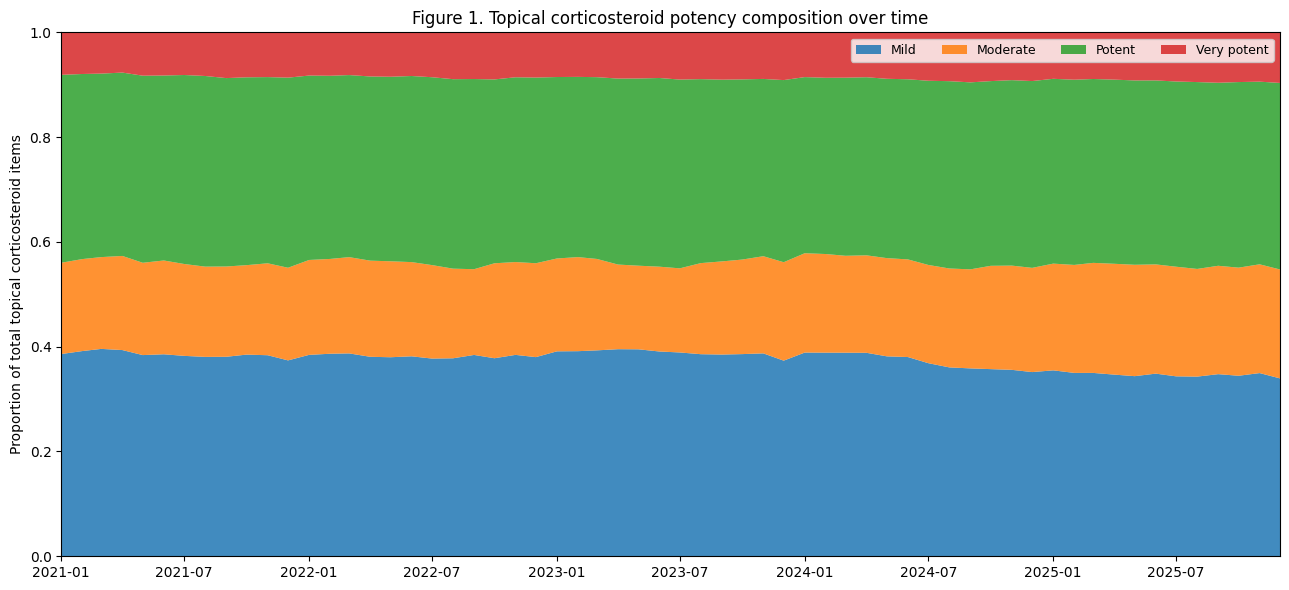

In [10]:
banner("POTENCY COMPOSITION")

monthly_tiers = (prescribing.groupby(["YEAR_MONTH", "TOPICAL_CLASS"])["ITEMS"].sum()
                            .unstack(fill_value=0).reindex(columns=TIER_ORDER, fill_value=0)
                            .sort_index())
monthly_share = monthly_tiers.div(monthly_tiers.sum(axis=1), axis=0)

composition = pd.DataFrame({
    "Potency tier":        [TIER_LABELS[t] for t in TIER_ORDER],
    "Mean share %":        (monthly_share.mean() * 100).round(1).values,
    "Min share %":         (monthly_share.min() * 100).round(1).values,
    "Max share %":         (monthly_share.max() * 100).round(1).values,
    "Final month share %": (monthly_share.iloc[-1] * 100).round(1).values,
})
print(composition.to_string(index=False))
print("\nMild + potent combined: {:.1f}% to {:.1f}% of monthly items".format(
    (monthly_share["1_Mild"] + monthly_share["3_Potent"]).min() * 100,
    (monthly_share["1_Mild"] + monthly_share["3_Potent"]).max() * 100))
save("table1_potency_composition", composition)

fig, ax = plt.subplots(figsize=(13, 6))
x = pd.to_datetime(monthly_share.index.astype(str), format="%Y%m")
ax.stackplot(x, *[monthly_share[t] for t in TIER_ORDER],
             labels=[TIER_LABELS[t] for t in TIER_ORDER], alpha=.85)
ax.set_ylim(0, 1); ax.set_xlim(x.min(), x.max())
ax.set_ylabel("Proportion of total topical corticosteroid items")
ax.set_title("Figure 1. Topical corticosteroid potency composition over time")
ax.legend(loc="upper right", ncol=4, fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure1_potency_share.png"), dpi=300)
plt.show()

## 8. Seasonality

**Fix C3.** The mean seasonal component is now printed by calendar month, so the peak and
trough can be stated accurately. The previous draft claimed a winter peak while citing
April 2021 and October 2021 as the extrema — April 2021 also coincides with the resumption
of routine primary care after the third lockdown.


SEASONAL-TREND DECOMPOSITION
60 monthly observations
Seasonal Strength Index: 0.6749

Mean seasonal component by calendar month (items above/below trend):
Jan    37566.0
Feb   -24492.0
Mar    74257.0
Apr    56711.0
May    17747.0
Jun    10158.0
Jul    11816.0
Aug   -47063.0
Sep   -32008.0
Oct   -33394.0
Nov   -17469.0
Dec   -45523.0

  PEAK   month: Mar  (+74,257 items)
  TROUGH month: Aug  (-47,063 items)

  ^ State THESE months in the manuscript. Do not describe the peak as winter unless this table says so.

Largest residuals (unexplained by trend or season):
DATE
2023-06-01     74525.0
2022-05-01     27435.0
2024-04-01     27057.0
2023-04-01   -130462.0
2022-04-01    -95221.0
2022-09-01    -55912.0
  written: outputs/seasonal_component_by_month.csv

SENSITIVITY excluding 2021: SSI = 0.7737, peak month = Mar, trough = Sep


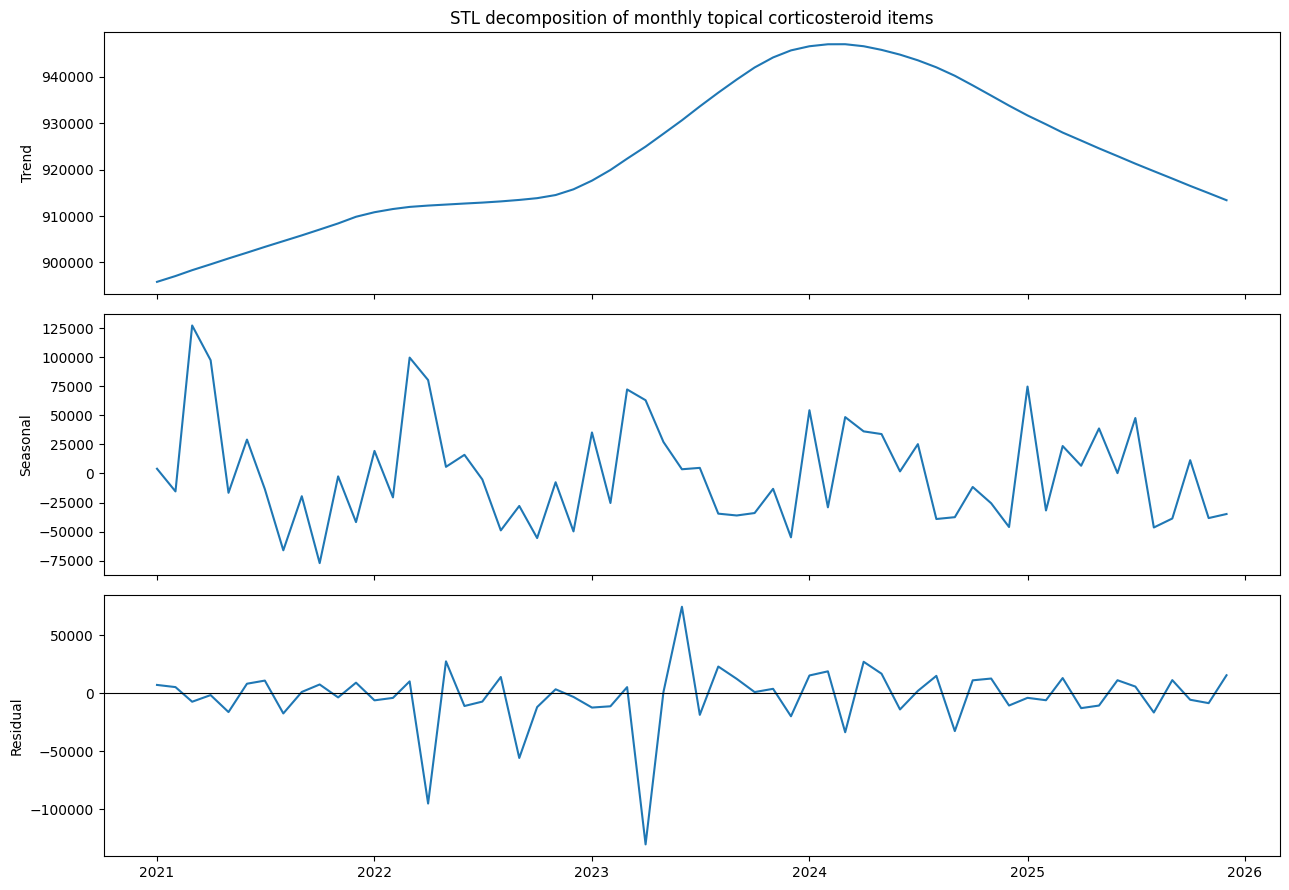

In [11]:
from statsmodels.tsa.seasonal import STL

banner("SEASONAL-TREND DECOMPOSITION")

ts = prescribing.groupby("DATE")["ITEMS"].sum().sort_index()
ts.index = pd.DatetimeIndex(ts.index).to_period("M").to_timestamp()
print(str(len(ts)) + " monthly observations")

stl = STL(ts, period=12, robust=True).fit()
ssi = max(0.0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
print("Seasonal Strength Index: {:.4f}".format(ssi))

seasonal_by_month = stl.seasonal.groupby(stl.seasonal.index.month).mean()
seasonal_by_month.index = ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"]
print("\nMean seasonal component by calendar month (items above/below trend):")
print(seasonal_by_month.round(0).to_string())
print("\n  PEAK   month: " + seasonal_by_month.idxmax() + "  ({:+,.0f} items)".format(seasonal_by_month.max()))
print("  TROUGH month: " + seasonal_by_month.idxmin() + "  ({:+,.0f} items)".format(seasonal_by_month.min()))
print("\n  ^ State THESE months in the manuscript. Do not describe the peak as winter "
      "unless this table says so.")

resid_extremes = pd.concat([stl.resid.nlargest(3), stl.resid.nsmallest(3)])
print("\nLargest residuals (unexplained by trend or season):")
print(resid_extremes.round(0).to_string())

RESULTS["seasonal_strength_index"] = ssi
RESULTS["seasonal_peak_month"] = seasonal_by_month.idxmax()
RESULTS["seasonal_trough_month"] = seasonal_by_month.idxmin()
save("seasonal_component_by_month", seasonal_by_month.reset_index().rename(
    columns={"index": "month", 0: "mean_seasonal_component"}))

# sensitivity: exclude 2021
ts_no21 = ts[ts.index.year > 2021]
if len(ts_no21) >= 24:
    stl2 = STL(ts_no21, period=12, robust=True).fit()
    ssi2 = max(0.0, 1 - np.var(stl2.resid) / np.var(stl2.seasonal + stl2.resid))
    sbm2 = stl2.seasonal.groupby(stl2.seasonal.index.month).mean()
    print("\nSENSITIVITY excluding 2021: SSI = {:.4f}, peak month = {}, trough = {}".format(
        ssi2, ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][sbm2.idxmax()-1],
        ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][sbm2.idxmin()-1]))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(stl.trend); axes[0].set_ylabel("Trend")
axes[1].plot(stl.seasonal); axes[1].set_ylabel("Seasonal")
axes[2].plot(stl.resid); axes[2].axhline(0, color="k", lw=.8); axes[2].set_ylabel("Residual")
axes[0].set_title("STL decomposition of monthly topical corticosteroid items")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure_stl.png"), dpi=300); plt.show()

## 9. Deprivation and prescribing volume

**Fix C1.** The previous specification was `Log_Items ~ IMD_Score + C(STP_CODE)` fitted to
presentation-level rows. IMD is constant within ICB, so it was perfectly collinear with the
ICB dummies — the coefficient came from a pseudo-inverse of a rank-deficient design, and the
row-level unit inflated N about 180-fold, producing SE = 0.003.

IMD cannot be identified from within-ICB variation. Three specifications are reported instead:

1. **Pooled OLS with month fixed effects and ICB-clustered SEs** — the primary estimate.
2. **Between-effects** — one observation per ICB; the cleanest cross-sectional statement.
3. **Two-way FE with IMD × time** — ICB fixed effects retained, identifying whether the
   deprivation gradient *widens or narrows*, which is the only thing FE can say about a
   time-invariant covariate.

The outcome is the log **rate** per 1,000 registered patients, not log items, so that ICB
population size is not doing the work.


DEPRIVATION AND PRESCRIBING VOLUME

1. Pooled OLS, month FE, ICB-clustered SE  [PRIMARY]
  beta = 0.0178   SE = 0.0021   p = 1.89e-17   95% CI [0.0137, 0.0219]
  => +1.79% change in prescribing rate per 1-unit IMD score
  N = 2,520 observations, 42 ICBs

2. Between-effects (ICB means)
  beta = 0.0178   SE = 0.0022   p = 5.608e-16   95% CI [0.0135, 0.0221]
  => +1.79% change in prescribing rate per 1-unit IMD score
  N = 42 observations, 42 ICBs

3. Two-way FE, IMD x time (gradient change)
  beta = 0.0000   SE = 0.0001   p = 0.669   95% CI [-0.0001, 0.0001]
  => +0.00% change in prescribing rate per 1-unit IMD score
  N = 2,520 observations, 42 ICBs
  Interpretation: the main effect of IMD is absorbed by the ICB fixed effects and is
  NOT estimable. This term tests only whether the gradient changes over time.

------------------------------------------------------------------------------
                                       specification   beta     se     p  ci_low  ci_high  pct_chan

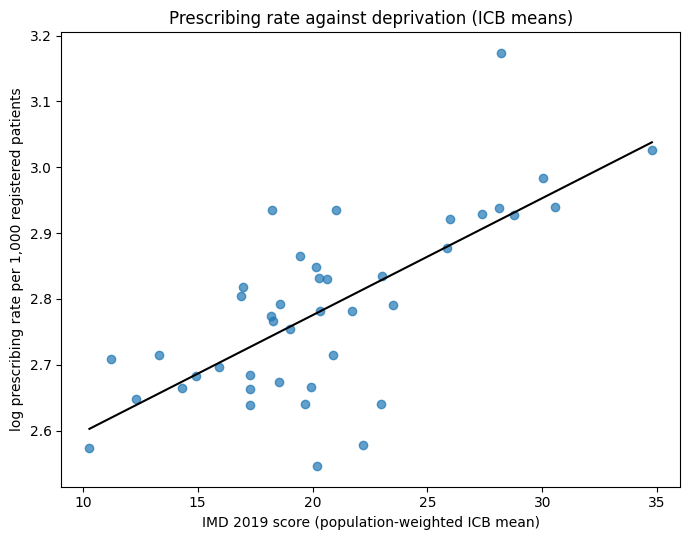

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

banner("DEPRIVATION AND PRESCRIBING VOLUME")

d = panel.copy()
d["IMD_C"] = d["IMD_SCORE"] - d["IMD_SCORE"].mean()   # centred, so intercepts are interpretable
d["TIME_C"] = d["TIME_IDX"] - d["TIME_IDX"].mean()

def report(model, term, label, n_units):
    b  = model.params[term]; se = model.bse[term]; p = model.pvalues[term]
    lo, hi = model.conf_int().loc[term]
    print("\n" + label)
    print("  beta = {:.4f}   SE = {:.4f}   p = {:.4g}   95% CI [{:.4f}, {:.4f}]".format(b, se, p, lo, hi))
    print("  => {:+.2f}% change in prescribing rate per 1-unit IMD score".format((np.exp(b) - 1) * 100))
    print("  N = {:,} observations, {} ICBs".format(int(model.nobs), n_units))
    return {"specification": label, "beta": b, "se": se, "p": p, "ci_low": lo, "ci_high": hi,
            "pct_change_per_imd_unit": (np.exp(b) - 1) * 100,
            "n_obs": int(model.nobs), "n_icb": n_units}

rows = []

# --- 1. pooled OLS, month FE, ICB-clustered SEs ---------------------------
m1 = smf.ols("LOG_RATE ~ IMD_C + C(YEAR_MONTH)", data=d).fit(
    cov_type="cluster", cov_kwds={"groups": d["ORG_CODE"]})
rows.append(report(m1, "IMD_C", "1. Pooled OLS, month FE, ICB-clustered SE  [PRIMARY]", d["ORG_CODE"].nunique()))

# --- 2. between-effects ---------------------------------------------------
btw = d.groupby("ORG_CODE").agg(LOG_RATE=("LOG_RATE", "mean"), IMD_C=("IMD_C", "first")).reset_index()
m2 = smf.ols("LOG_RATE ~ IMD_C", data=btw).fit(cov_type="HC3")
rows.append(report(m2, "IMD_C", "2. Between-effects (ICB means)", len(btw)))

# --- 3. two-way FE with IMD x time ---------------------------------------
m3 = smf.ols("LOG_RATE ~ IMD_C:TIME_C + C(ORG_CODE) + C(YEAR_MONTH)", data=d).fit(
    cov_type="cluster", cov_kwds={"groups": d["ORG_CODE"]})
rows.append(report(m3, "IMD_C:TIME_C", "3. Two-way FE, IMD x time (gradient change)", d["ORG_CODE"].nunique()))
print("  Interpretation: the main effect of IMD is absorbed by the ICB fixed effects and is")
print("  NOT estimable. This term tests only whether the gradient changes over time.")

volume_results = pd.DataFrame(rows)
print("\n" + "-" * 78)
print(volume_results.round(4).to_string(index=False))
save("model_deprivation_volume", volume_results)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(btw["IMD_C"] + d["IMD_SCORE"].mean(), btw["LOG_RATE"], alpha=.7)
xs = np.linspace(btw["IMD_C"].min(), btw["IMD_C"].max(), 50)
ax.plot(xs + d["IMD_SCORE"].mean(), m2.params["Intercept"] + m2.params["IMD_C"] * xs, color="k")
ax.set_xlabel("IMD 2019 score (population-weighted ICB mean)")
ax.set_ylabel("log prescribing rate per 1,000 registered patients")
ax.set_title("Prescribing rate against deprivation (ICB means)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure_deprivation_volume.png"), dpi=300); plt.show()

## 10. Deprivation and potency composition

**Fix C5.** The previous model's numerator was a count of matching **data rows** while its
denominator summed **dispensed items**, so the modelled quantity was rows ÷ items. The
symptom was visible in the output: an intercept of −4.129 implies a strong-steroid share of
about 1.6%, against roughly 48% observed.

Here both numerator and denominator are item sums, standard errors are clustered on ICB
(60 monthly repeats per ICB are not independent observations), and three sensitivity
analyses address the reviewer's question about distributional assumptions (**C2**).

In [13]:
banner("DEPRIVATION AND POTENCY COMPOSITION")

d = panel.copy()
d["IMD_C"] = d["IMD_SCORE"] - d["IMD_SCORE"].mean()
X = sm.add_constant(d[["IMD_C"]])

print("Sanity check — mean strong steroid ratio: {:.4f}".format(d["STRONG_RATIO"].mean()))
print("If a fitted intercept implies a value far from this, the outcome is misconstructed.\n")

frac_rows = []

# --- primary: fractional logit, HC3 --------------------------------------
# Observations are 60 monthly repeats within each of ~42 ICBs. HC3 alone treats them as
# independent and badly understates the SE; cluster on ICB.
CLUS = {"groups": d["ORG_CODE"]}
m = sm.GLM(d["STRONG_RATIO"], X, family=sm.families.Binomial()).fit(
    cov_type="cluster", cov_kwds=CLUS)
m_hc3 = sm.GLM(d["STRONG_RATIO"], X, family=sm.families.Binomial()).fit(cov_type="HC3")
print("   SE under HC3 (independence): {:.5f}   under ICB clustering: {:.5f}".format(
    m_hc3.bse["IMD_C"], m.bse["IMD_C"]))
implied = 1 / (1 + np.exp(-m.params["const"]))
print("1. Fractional logit, ICB-clustered SE  [PRIMARY]")
print("   beta(IMD) = {:.4f}  SE = {:.4f}  z = {:.3f}  p = {:.4g}  95% CI [{:.4f}, {:.4f}]".format(
    m.params["IMD_C"], m.bse["IMD_C"], m.tvalues["IMD_C"], m.pvalues["IMD_C"],
    *m.conf_int().loc["IMD_C"]))
print("   intercept {:.4f} -> implied strong ratio at mean deprivation {:.4f}".format(
    m.params["const"], implied))
assert abs(implied - d["STRONG_RATIO"].mean()) < 0.10, \
    "Implied intercept does not match the observed mean — outcome is misconstructed."
frac_rows.append({"model": "Fractional logit (ICB-clustered)", "beta": m.params["IMD_C"],
                  "se": m.bse["IMD_C"], "p": m.pvalues["IMD_C"], "n": int(m.nobs)})

# --- 2. item-weighted (grouped binomial) ---------------------------------
mw = sm.GLM(d["STRONG_RATIO"], X, family=sm.families.Binomial(),
            var_weights=d["TOTAL_ITEMS"]).fit(cov_type="cluster", cov_kwds=CLUS)
print("\n2. Item-weighted grouped binomial (large ICBs weighted more)")
print("   beta(IMD) = {:.4f}  p = {:.4g}".format(mw.params["IMD_C"], mw.pvalues["IMD_C"]))
frac_rows.append({"model": "Item-weighted binomial", "beta": mw.params["IMD_C"],
                  "se": mw.bse["IMD_C"], "p": mw.pvalues["IMD_C"], "n": int(mw.nobs)})

# --- 3. beta regression via logit-transformed outcome --------------------
eps = 1e-6
y_adj = d["STRONG_RATIO"].clip(eps, 1 - eps)
mb = sm.OLS(np.log(y_adj / (1 - y_adj)), X).fit(cov_type="cluster",
                                                cov_kwds={"groups": d["ORG_CODE"]})
print("\n3. Log-odds OLS, ICB-clustered SE")
print("   beta(IMD) = {:.4f}  p = {:.4g}".format(mb.params["IMD_C"], mb.pvalues["IMD_C"]))
frac_rows.append({"model": "Log-odds OLS (clustered)", "beta": mb.params["IMD_C"],
                  "se": mb.bse["IMD_C"], "p": mb.pvalues["IMD_C"], "n": int(mb.nobs)})

# --- 4. Dirichlet regression over all four tiers -------------------------
print("\n4. Dirichlet regression across all four tiers (adding-up constraint enforced)")
try:
    from scipy.optimize import minimize
    from scipy.special import gammaln
    Y = d[[t + "_RATIO" for t in TIER_ORDER]].clip(1e-6, 1).values
    Y = Y / Y.sum(axis=1, keepdims=True)
    Xd = np.column_stack([np.ones(len(d)), d["IMD_C"].values])
    K, P = Y.shape[1], Xd.shape[1]

    def nll(theta):
        B = theta[:K * P].reshape(P, K)
        phi = np.exp(theta[-1])
        alpha = np.exp(Xd @ B) * phi
        return -np.sum(gammaln(alpha.sum(1)) - gammaln(alpha).sum(1)
                       + ((alpha - 1) * np.log(Y)).sum(1))

    init = np.concatenate([np.zeros(K * P), [np.log(50)]])
    res = minimize(nll, init, method="L-BFGS-B")
    B = res.x[:K * P].reshape(P, K)
    print("   converged: " + str(res.success))
    print("   IMD coefficient by tier (log-alpha scale, relative effects):")
    for i, t in enumerate(TIER_ORDER):
        print("     " + TIER_LABELS[t].ljust(12) + "{:+.5f}".format(B[1, i]))
    print("   Interpretation: coefficients near zero and of inconsistent sign across tiers")
    print("   indicate no systematic shift in composition with deprivation.")
    frac_rows.append({"model": "Dirichlet (potent tier)", "beta": B[1, 2],
                      "se": np.nan, "p": np.nan, "n": len(d)})
except Exception as exc:
    print("   Dirichlet fit failed: " + str(exc) + " — report the three models above.")

# --- per-tier fractional logits ------------------------------------------
print("\nPer-tier fractional logits (IMD coefficient):")
tier_rows = []
for t in TIER_ORDER:
    mt = sm.GLM(d[t + "_RATIO"], X, family=sm.families.Binomial()).fit(
        cov_type="cluster", cov_kwds=CLUS)
    tier_rows.append({"tier": TIER_LABELS[t], "beta": mt.params["IMD_C"],
                      "se": mt.bse["IMD_C"], "p": mt.pvalues["IMD_C"]})
    print("  " + TIER_LABELS[t].ljust(12) +
          "beta = {:+.5f}  p = {:.4g}".format(mt.params["IMD_C"], mt.pvalues["IMD_C"]))

potency_results = pd.DataFrame(frac_rows)
print("\n" + potency_results.round(5).to_string(index=False))
save("model_deprivation_potency", potency_results)
save("model_deprivation_potency_by_tier", pd.DataFrame(tier_rows))


DEPRIVATION AND POTENCY COMPOSITION
Sanity check — mean strong steroid ratio: 0.4436
If a fitted intercept implies a value far from this, the outcome is misconstructed.

   SE under HC3 (independence): 0.00049   under ICB clustering: 0.00364
1. Fractional logit, ICB-clustered SE  [PRIMARY]
   beta(IMD) = -0.0084  SE = 0.0036  z = -2.313  p = 0.02072  95% CI [-0.0155, -0.0013]
   intercept -0.2266 -> implied strong ratio at mean deprivation 0.4436

2. Item-weighted grouped binomial (large ICBs weighted more)
   beta(IMD) = -0.0109  p = 0.01358

3. Log-odds OLS, ICB-clustered SE
   beta(IMD) = -0.0085  p = 0.01993

4. Dirichlet regression across all four tiers (adding-up constraint enforced)


/usr/local/lib/python3.13/dist-packages/statsmodels/genmod/generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


   converged: True
   IMD coefficient by tier (log-alpha scale, relative effects):
     Mild        +0.00371
     Moderate    +0.00395
     Potent      -0.00397
     Very potent -0.00724
   Interpretation: coefficients near zero and of inconsistent sign across tiers
   indicate no systematic shift in composition with deprivation.

Per-tier fractional logits (IMD coefficient):
  Mild        beta = +0.00594  p = 0.07244
  Moderate    beta = +0.00451  p = 0.05022
  Potent      beta = -0.00615  p = 0.0328
  Very potent beta = -0.00832  p = 0.1101

                           model     beta      se       p    n
Fractional logit (ICB-clustered) -0.00841 0.00364 0.02072 2520
          Item-weighted binomial -0.01091 0.00442 0.01358 2520
        Log-odds OLS (clustered) -0.00853 0.00367 0.01993 2520
         Dirichlet (potent tier) -0.00397     NaN     NaN 2520
  written: outputs/model_deprivation_potency.csv
  written: outputs/model_deprivation_potency_by_tier.csv


## 11. Temporal stability

**Fixes B7 and B12.** The previous notebook assigned each ICB-month to whichever tier had the
highest **within-tier z-score** — the tier most unusually elevated relative to its own
baseline, which is not the tier accounting for the largest share of prescribing. Table 4's
matrix came from that model, while Table 1's steady state and forecast came from a *different*
matrix fitted to the national market-share series.

Here the dominant-tier definition is primary, the steady state and forecast are derived from
**the same** matrix as the reported transitions, and the z-score version is retained as a
labelled sensitivity so the two can be compared directly.

An ICC is also reported (**C4**), which lets a reader verify persistence without relying on
the Markov specification at all.

In [14]:
banner("TEMPORAL STABILITY")

def transition_matrix(state_frame, state_col):
    s = state_frame.sort_values(["ORG_CODE", "YEAR_MONTH"]).copy()
    ym = s["YEAR_MONTH"].astype(int)
    s["MONTH_IDX"] = (ym // 100) * 12 + (ym % 100)
    s["NEXT"] = s.groupby("ORG_CODE")[state_col].shift(-1)
    s["NEXT_IDX"] = s.groupby("ORG_CODE")["MONTH_IDX"].shift(-1)
    # only consecutive months count as a transition
    s = s[s["NEXT"].notna() & ((s["NEXT_IDX"] - s["MONTH_IDX"]) == 1)]
    M = pd.crosstab(s[state_col], s["NEXT"], normalize="index")
    M = M.reindex(index=TIER_ORDER, columns=TIER_ORDER, fill_value=0.0)
    # States never occupied give all-zero rows. Left as zeros they leak probability mass,
    # so a 12-step forecast no longer sums to 1. Make them absorbing identity rows.
    for t in TIER_ORDER:
        if M.loc[t].sum() == 0:
            M.loc[t, t] = 1.0
    return M, len(s)


def steady_state(M):
    vals, vecs = np.linalg.eig(M.values.T)
    v = np.real(vecs[:, np.argmin(np.abs(vals - 1))])
    v = np.maximum(v, 0)
    return pd.Series(v / v.sum(), index=M.index)


def summarise(M, n_trans, label, state_counts):
    print("\n" + "-" * 78)
    print(label + "   (" + str(n_trans) + " consecutive-month transitions)")
    print("-" * 78)
    print("State occupancy: " + ", ".join(
        TIER_LABELS[t] + " " + str(int(state_counts.get(t, 0))) for t in TIER_ORDER))
    disp = M.copy()
    disp.index = [TIER_LABELS[t] for t in disp.index]
    disp.columns = [TIER_LABELS[t] for t in disp.columns]
    print("\nTransition probability matrix (row = month t, column = month t+1):")
    print(disp.round(3).to_string())
    dur = pd.Series({TIER_LABELS[t]: (1 / (1 - M.loc[t, t]) if M.loc[t, t] < 1 else np.inf)
                     for t in TIER_ORDER})
    print("\nSelf-transition probability and expected months in state:")
    for t in TIER_ORDER:
        occ = int(state_counts.get(t, 0))
        if occ == 0:
            print("  " + TIER_LABELS[t].ljust(12) + "never occupied - no estimate")
        else:
            d_ = dur[TIER_LABELS[t]]
            d_txt = "never leaves" if not np.isfinite(d_) else "{:.1f} months".format(d_)
            print("  " + TIER_LABELS[t].ljust(12) + "p = {:.3f}   {}".format(M.loc[t, t], d_txt))

    # --- degeneracy guard --------------------------------------------------
    occupied = int((state_counts.reindex(TIER_ORDER).fillna(0) > 0).sum())
    top_frac = state_counts.max() / max(state_counts.sum(), 1)
    if occupied < len(TIER_ORDER) or top_frac > 0.75:
        print("\n  *** WARNING: this state definition is degenerate. " +
              "{:.0f}% of ICB-months sit in a single state".format(top_frac * 100))
        print("      and only " + str(occupied) + " of 4 states are ever occupied. Rows for the")
        print("      unoccupied states are not estimated at all and have been set to identity")
        print("      so probability mass is conserved; they carry no information.")
        print("      A high self-transition probability here is high BY CONSTRUCTION, not")
        print("      because prescribing is unusually persistent.")
        print("      Do NOT report it as evidence of persistence. Use the ICC and the")
        print("      first-year vs last-year correlation in the next section instead, or")
        print("      define states on a continuous measure such as the strong steroid ratio")
        print("      split at its quartiles.")
    ss = steady_state(M)
    return disp, dur, ss


# ---- PRIMARY: dominant tier ---------------------------------------------
panel["STATE_DOMINANT"] = panel[[t + "_RATIO" for t in TIER_ORDER]].idxmax(axis=1).str.replace("_RATIO", "", regex=False)
M_dom, n_dom = transition_matrix(panel, "STATE_DOMINANT")
disp_dom, dur_dom, ss_dom = summarise(M_dom, n_dom, "PRIMARY — state = dominant potency tier (largest share)",
                                      panel["STATE_DOMINANT"].value_counts())

panel_tiers = (panel.groupby("YEAR_MONTH")[TIER_ORDER].sum())
panel_share = panel_tiers.div(panel_tiers.sum(axis=1), axis=0).sort_index()
final_share = panel_share.iloc[-1].reindex(TIER_ORDER)
forecast12 = pd.Series(final_share.values @ np.linalg.matrix_power(M_dom.values, 12), index=TIER_ORDER)
if abs(forecast12.sum() - 1) > 0.01:
    raise RuntimeError("Markov forecast sums to {:.3f}, not 1 - probability mass is leaking "
                       "from the transition matrix.".format(forecast12.sum()))

table1 = pd.DataFrame({
    "Potency tier":     [TIER_LABELS[t] for t in TIER_ORDER],
    "Mean share %":     (panel_share.mean().reindex(TIER_ORDER) * 100).round(1).values,
    "Final month %":    (final_share * 100).round(1).values,
    "12-month forecast %": (forecast12 * 100).round(1).values,
    "Steady state %":   (ss_dom.reindex(TIER_ORDER) * 100).round(1).values,
})
print("\nSteady state and forecast — SAME matrix as above (fixes B12):")
print(table1.to_string(index=False))
save("table1_composition_and_markov", table1)
save("table4_markov_transitions_dominant", disp_dom.reset_index().rename(columns={"index": "from_state"}))

# ---- SENSITIVITY: z-score spike (the previous definition) ---------------
long = panel.melt(id_vars=["ORG_CODE", "YEAR_MONTH"], value_vars=TIER_ORDER,
                  var_name="TIER", value_name="ITEMS")
long["Z"] = long.groupby("TIER")["ITEMS"].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
spike = long.loc[long.groupby(["ORG_CODE", "YEAR_MONTH"])["Z"].idxmax(),
                 ["ORG_CODE", "YEAR_MONTH", "TIER"]].rename(columns={"TIER": "STATE_Z"})
M_z, n_z = transition_matrix(spike, "STATE_Z")
disp_z, dur_z, ss_z = summarise(M_z, n_z, "SENSITIVITY — state = highest within-tier z-score (previous definition)",
                                spike["STATE_Z"].value_counts())
save("table4_markov_transitions_zscore_sensitivity",
     disp_z.reset_index().rename(columns={"index": "from_state"}))

print("\n" + "=" * 78)
print("Compare the two matrices before choosing which to report. They answer different")
print("questions: 'does the same tier keep dominating?' versus 'does the same tier keep")
print("spiking?'. The manuscript should describe whichever is reported, accurately.")


TEMPORAL STABILITY

------------------------------------------------------------------------------
PRIMARY — state = dominant potency tier (largest share)   (2478 consecutive-month transitions)
------------------------------------------------------------------------------
State occupancy: Mild 1663, Moderate 0, Potent 857, Very potent 0

Transition probability matrix (row = month t, column = month t+1):
              Mild  Moderate  Potent  Very potent
Mild         0.937       0.0   0.063          0.0
Moderate     0.000       1.0   0.000          0.0
Potent       0.104       0.0   0.896          0.0
Very potent  0.000       0.0   0.000          1.0

Self-transition probability and expected months in state:
  Mild        p = 0.937   15.9 months
  Moderate    never occupied - no estimate
  Potent      p = 0.896   9.6 months
  Very potent never occupied - no estimate

  *** WARNING: this state definition is degenerate. 66% of ICB-months sit in a single state
      and only 2 of 4 states 

## 12. Descriptive support for persistence

**Fix C4.** Requested at review: an ICC quantifying how much of the variance in prescribing
sits between ICBs rather than within them, plus two plots a clinical reader can inspect
directly. These let the persistence claim stand on descriptive evidence rather than on the
Markov specification alone.


PERSISTENCE — DESCRIPTIVE SUPPORT
log prescribing rate    ICC = 0.819   (between 0.01838, within 0.00405)
strong steroid ratio    ICC = 0.880   (between 0.00084, within 0.00012)

ICC is the proportion of variance attributable to stable between-ICB differences.


/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


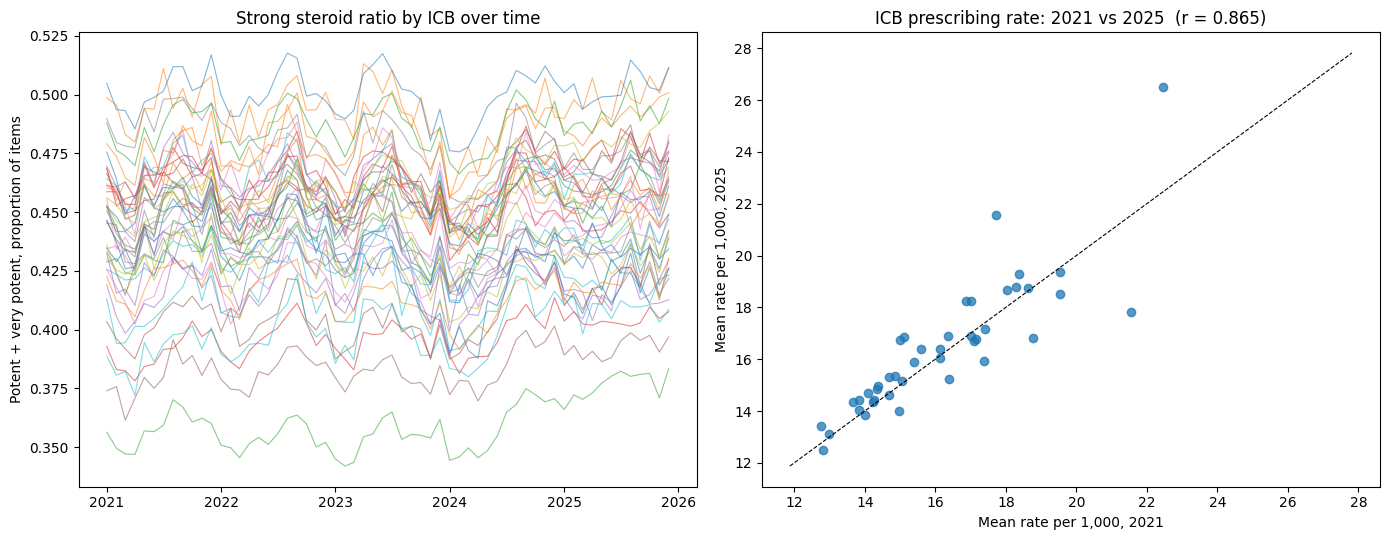


Correlation between first-year and last-year ICB prescribing rate: r = 0.865


In [15]:
banner("PERSISTENCE — DESCRIPTIVE SUPPORT")

def icc(df, outcome):
    m = smf.mixedlm(outcome + " ~ 1", df, groups=df["ORG_CODE"]).fit(reml=True)
    between = float(m.cov_re.iloc[0, 0]); within = float(m.scale)
    return between / (between + within), between, within

for outcome, label in [("LOG_RATE", "log prescribing rate"), ("STRONG_RATIO", "strong steroid ratio")]:
    try:
        val, b, w = icc(panel, outcome)
        print(label.ljust(24) + "ICC = {:.3f}   (between {:.5f}, within {:.5f})".format(val, b, w))
        RESULTS["icc_" + outcome.lower()] = val
    except Exception as exc:
        print(label.ljust(24) + "ICC failed: " + str(exc))
print("\nICC is the proportion of variance attributable to stable between-ICB differences.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for org, g in panel.groupby("ORG_CODE"):
    axes[0].plot(g["DATE"], g["STRONG_RATIO"], lw=.8, alpha=.55)
axes[0].set_title("Strong steroid ratio by ICB over time")
axes[0].set_ylabel("Potent + very potent, proportion of items")

first_year, last_year = panel["YEAR"].min(), panel["YEAR"].max()
cmp_df = (panel[panel["YEAR"].isin([first_year, last_year])]
          .groupby(["ORG_CODE", "YEAR"])["RATE_PER_1000"].mean().unstack())
cmp_df = cmp_df.dropna()
axes[1].scatter(cmp_df[first_year], cmp_df[last_year], alpha=.75)
lims = [cmp_df.min().min() * .95, cmp_df.max().max() * 1.05]
axes[1].plot(lims, lims, "k--", lw=.8)
r = cmp_df.corr().iloc[0, 1]
axes[1].set_xlabel("Mean rate per 1,000, " + str(first_year))
axes[1].set_ylabel("Mean rate per 1,000, " + str(last_year))
axes[1].set_title("ICB prescribing rate: {} vs {}  (r = {:.3f})".format(first_year, last_year, r))
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure_persistence.png"), dpi=300); plt.show()

print("\nCorrelation between first-year and last-year ICB prescribing rate: r = {:.3f}".format(r))
RESULTS["rate_stability_r"] = r

## 13. Spatial analysis

**Fix B6.** The previous merge joined prescribing data to boundary polygons on cleaned name
strings, logged `Successfully matched and dissolved 37 spatial geometries`, and dropped five
ICBs without comment. Cornwall and the Isles of Scilly was retained despite having no
contiguous neighbours, entering the weights matrix with an empty row.

Here the merge is on ODS code, unmatched units are listed, and islands are excluded
explicitly and reported. Moran's I is computed on the **population-denominated rate**.

In [16]:
import geopandas as gpd
import libpysal as ps
from esda.moran import Moran, Moran_Local

banner("SPATIAL ANALYSIS")

def load_icb_boundaries():
    """Find and load an ICB boundary layer from the ONS portal."""
    services = find_ons_service(["Integrated_Care_Boards"], must_exclude=["Sub"])
    if not services:
        raise RuntimeError(
            "No ICB boundary service found. Download a boundary file from "
            "https://geoportal.statistics.gov.uk/ and load it with gpd.read_file().")
    print("Boundary service candidates: " + ", ".join(services[:3]))
    last = None
    for name in services[:3]:
        url = (ONS_FS_ROOT + "/" + name +
               "/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson")
        try:
            r = HTTP.get(url, timeout=180); r.raise_for_status()
            g = gpd.read_file(r.text)
            if len(g):
                print("  using " + name + " -> " + str(len(g)) + " polygons")
                return g
        except Exception as exc:
            last = exc
            print("  " + name + " failed: " + str(exc)[:70])
    raise RuntimeError("All boundary services failed. Last error: " + str(last))

icb_summary = (panel.groupby("ORG_CODE")
                    .agg(TOTAL_ITEMS=("TOTAL_ITEMS", "sum"),
                         LIST_SIZE=("LIST_SIZE", "mean"),
                         IMD_SCORE=("IMD_SCORE", "first"),
                         STRONG_RATIO=("STRONG_RATIO", "mean"),
                         **{t + "_RATIO": (t + "_RATIO", "mean") for t in TIER_ORDER})
                    .reset_index())
icb_summary["RATE_PER_1000"] = icb_summary["TOTAL_ITEMS"] / icb_summary["LIST_SIZE"] * 1000

gdf = load_icb_boundaries()

ods_col = next((c for c in gdf.columns if c.upper().startswith("ICB") and c.upper().endswith("CDH")), None)
if ods_col is not None:
    gdf["ORG_CODE"] = gdf[ods_col].astype(str).str.strip().str.upper()
    print("Joining on ODS code field: " + ods_col)
else:
    # fall back to the ONS code, translated via the crosswalk built during IMD linkage
    ons_col = next((c for c in gdf.columns
                    if c.upper().startswith("ICB") and c.upper().endswith("CD")), None)
    if ons_col is None or icb_crosswalk is None:
        raise ValueError(
            "Boundary layer has neither an ODS code (ICB..CDH) nor a usable ONS code, "
            "and no crosswalk is available.\nFields: " + str(gdf.columns.tolist()) +
            "\nDo NOT fall back to name matching - that is what silently dropped 5 ICBs "
            "from the previous spatial analysis.")
    print("No ODS field on the boundary layer; joining via ONS code " + ons_col +
          " and the ODS crosswalk")
    gdf["ICB_ONS_CODE"] = gdf[ons_col].astype(str).str.strip().str.upper()
    gdf = gdf.merge(icb_crosswalk, on="ICB_ONS_CODE", how="left")
    if gdf["ORG_CODE"].isna().any():
        print("  WARNING: " + str(int(gdf["ORG_CODE"].isna().sum())) +
              " polygons could not be given an ODS code and will not match.")

merged = gdf.merge(icb_summary, on="ORG_CODE", how="inner")
unmatched_data = set(icb_summary["ORG_CODE"]) - set(gdf["ORG_CODE"])
unmatched_geom = set(gdf["ORG_CODE"]) - set(icb_summary["ORG_CODE"])
print("Boundary polygons: " + str(len(gdf)) + " | ICBs in data: " + str(len(icb_summary)) +
      " | matched on ODS code: " + str(len(merged)))
if unmatched_data:
    print("  In data, no polygon: " + str(sorted(unmatched_data)))
if unmatched_geom:
    print("  Polygon, no data:    " + str(sorted(unmatched_geom)))

if merged["ORG_CODE"].duplicated().any():
    merged = merged.dissolve(by="ORG_CODE", as_index=False, aggfunc="first")
merged = merged.reset_index(drop=True)

def queen_weights(gdf_in):
    ids = gdf_in["ORG_CODE"].tolist()
    try:
        return ps.weights.Queen.from_dataframe(gdf_in, ids=ids, use_index=False)
    except TypeError:
        return ps.weights.Queen.from_dataframe(gdf_in, ids=ids)


w = queen_weights(merged)
if w.islands:
    print("\nIslands with no contiguous neighbours: " + str(list(w.islands)))
    print("  Excluding them — an island contributes nothing to a spatial lag model.")
    merged = merged[~merged["ORG_CODE"].isin(w.islands)].reset_index(drop=True)
    w = queen_weights(merged)
w.transform = "r"
print("\nSpatial units in the final weights matrix: " + str(len(merged)))
print("Mean neighbours per unit: {:.2f}".format(np.mean([len(v) for v in w.neighbors.values()])))

# ---- Moran's I ----------------------------------------------------------
np.random.seed(42)
mi = Moran(merged["RATE_PER_1000"].values, w, permutations=MORAN_PERMUTATIONS)
print("\nGlobal Moran's I, prescribing rate per 1,000: I = {:.4f}, p = {:.4f} ({} permutations)".format(
    mi.I, mi.p_sim, MORAN_PERMUTATIONS))
mi_strong = Moran(merged["STRONG_RATIO"].values, w, permutations=MORAN_PERMUTATIONS)
print("Global Moran's I, strong steroid ratio:      I = {:.4f}, p = {:.4f}".format(
    mi_strong.I, mi_strong.p_sim))
print("\n  Note: the previous run computed Moran's I on items / 100 (constant denominator).")
print("  The value above is the first population-denominated estimate.")

lisa = Moran_Local(merged["RATE_PER_1000"].values, w, permutations=MORAN_PERMUTATIONS)
labels = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
merged["LISA"] = np.where(lisa.p_sim < .05, pd.Series(lisa.q).map(labels), "Not significant")
print("\nLISA cluster membership (p < 0.05):")
print(merged["LISA"].value_counts().to_string())

RESULTS["morans_i_rate"] = mi.I; RESULTS["morans_i_rate_p"] = mi.p_sim
RESULTS["morans_i_strong_ratio"] = mi_strong.I; RESULTS["morans_i_strong_ratio_p"] = mi_strong.p_sim
save("spatial_icb_summary", merged.drop(columns="geometry"))


SPATIAL ANALYSIS
Boundary service candidates: Integrated_Care_Boards_July_2022_EN_BFE_2022, Integrated_Care_Boards_July_2022_EN_BFC_2022, Integrated_Care_Boards_April_2026_Boundaries_EN_BSC
  using Integrated_Care_Boards_July_2022_EN_BFE_2022 -> 42 polygons
No ODS field on the boundary layer; joining via ONS code ICB22CD and the ODS crosswalk
Boundary polygons: 42 | ICBs in data: 42 | matched on ODS code: 42

Spatial units in the final weights matrix: 42
Mean neighbours per unit: 4.90

Global Moran's I, prescribing rate per 1,000: I = 0.3471, p = 0.0004 (9999 permutations)
Global Moran's I, strong steroid ratio:      I = 0.1384, p = 0.0533

  Note: the previous run computed Moran's I on items / 100 (constant denominator).
  The value above is the first population-denominated estimate.

LISA cluster membership (p < 0.05):
LISA
Not significant    29
Low-Low             6
High-High           4
Low-High            2
High-Low            1
  written: outputs/spatial_icb_summary.csv



SPATIAL LAG REGRESSION
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
                      Outcome    rho  rho_p  beta_IMD  beta_IMD_p  pseudo_R2  n
                         Mild 0.1387 0.5141   0.00131      0.0535      0.104 42
                     Moderate 0.2718 0.1738   0.00072      0.1901      0.089 42
                       Potent 0.2116 0.2960  -0.00138      0.0246      0.141 42
                  Very potent 0.3257 0.0891  -0.00057      0.1382      0.136 42
Strong (potent + very potent) 0.2930 0.1232  -0.00195      0.0120      0.198 42

n = 42 ICBs. Report this number and the exclusions above;
do not describe the reduction from 42 as an island exclusion unless it is one.
  written: outputs/table3_spatial_lag_models.csv


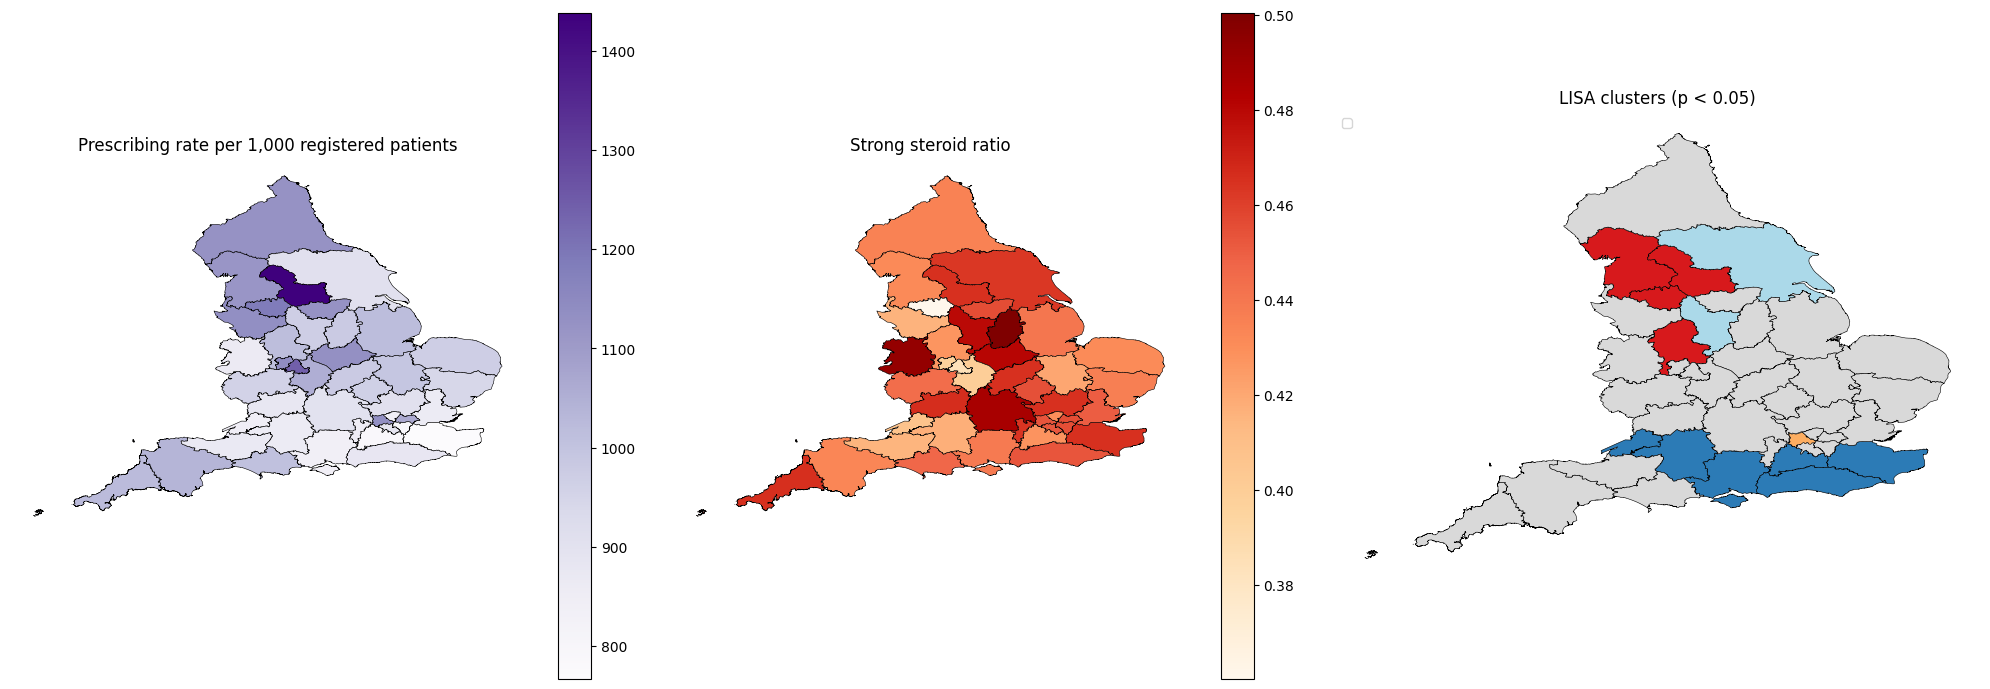

In [17]:
import spreg

banner("SPATIAL LAG REGRESSION")

spatial_rows = []
for t in TIER_ORDER + ["STRONG"]:
    col = "STRONG_RATIO" if t == "STRONG" else t + "_RATIO"
    lbl = "Strong (potent + very potent)" if t == "STRONG" else TIER_LABELS[t]
    y = merged[[col]].values
    X = merged[["IMD_SCORE"]].values
    try:
        m = spreg.ML_Lag(y, X, w=w, name_y=col, name_x=["IMD_SCORE"], name_ds="ICB")
        rho_val = float(np.ravel(m.rho)[0])
        rho_p = float(m.z_stat[-1][1])
        spatial_rows.append({
            "Outcome": lbl,
            "rho": round(rho_val, 4),
            "rho_p": round(rho_p, 4),
            "beta_IMD": round(float(m.betas[1][0]), 5),
            "beta_IMD_p": round(float(m.z_stat[1][1]), 4),
            "pseudo_R2": round(float(m.pr2), 3),
            "n": int(m.n)})
    except Exception as exc:
        print("  " + lbl + ": MODEL FAILED — " + str(exc))
        spatial_rows.append({"Outcome": lbl, "rho": np.nan, "rho_p": np.nan,
                             "beta_IMD": np.nan, "beta_IMD_p": np.nan,
                             "pseudo_R2": np.nan, "n": len(merged),
                             "note": "did not converge — " + str(exc)[:80]})

spatial_results = pd.DataFrame(spatial_rows)
print(spatial_results.to_string(index=False))
if spatial_results["rho"].isna().any():
    print("\nOne or more models did not converge. Do not report those tiers as null results —")
    print("a non-converged model is not evidence of no spatial effect. Investigate before submitting.")
print("\nn = " + str(len(merged)) + " ICBs. Report this number and the exclusions above;")
print("do not describe the reduction from 42 as an island exclusion unless it is one.")
save("table3_spatial_lag_models", spatial_results)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
merged.plot(column="RATE_PER_1000", cmap="Purples", edgecolor="k", lw=.4, legend=True, ax=axes[0])
axes[0].set_title("Prescribing rate per 1,000 registered patients")
merged.plot(column="STRONG_RATIO", cmap="OrRd", edgecolor="k", lw=.4, legend=True, ax=axes[1])
axes[1].set_title("Strong steroid ratio")
cmap = {"High-High": "#d7191c", "Low-Low": "#2c7bb6", "Low-High": "#abd9e9",
        "High-Low": "#fdae61", "Not significant": "#d9d9d9"}
for lab, sub in merged.groupby("LISA"):
    sub.plot(ax=axes[2], color=cmap.get(lab, "#d9d9d9"), edgecolor="k", lw=.4, label=lab)
axes[2].set_title("LISA clusters (p < 0.05)"); axes[2].legend(loc="upper left", fontsize=9)
for a in axes:
    a.axis("off"); a.set_aspect("equal")     # fixes the stretched-panel problem (D6)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "figure3_spatial.png"), dpi=300); plt.show()

## 14. Cross-lagged panel model

Tests whether higher mild/moderate prescribing in one month precedes lower potent prescribing
in the next. Retained with ICB fixed effects and both lagged terms.

This establishes temporal ordering only. It cannot separate treatment escalation within
patients from parallel growth in population-level prescribing, and should not be described
as demonstrating causation.

In [18]:
banner("CROSS-LAGGED PANEL MODEL")

c = panel.copy()
c["MILD_MOD"] = c["1_Mild"] + c["2_Moderate"]
c["STRONG"]   = c["3_Potent"] + c["4_Very_Potent"]
for col in ["MILD_MOD", "STRONG"]:
    lg = np.log1p(c[col])
    c["Z_" + col] = (lg - lg.mean()) / lg.std()
    c["LAG_Z_" + col] = c.groupby("ORG_CODE")["Z_" + col].shift(1)
c = c.dropna(subset=["LAG_Z_MILD_MOD", "LAG_Z_STRONG"])

m = smf.ols("Z_STRONG ~ LAG_Z_STRONG + LAG_Z_MILD_MOD + C(ORG_CODE)", data=c).fit(
    cov_type="cluster", cov_kwds={"groups": c["ORG_CODE"]})
for term in ["LAG_Z_MILD_MOD", "LAG_Z_STRONG"]:
    lo, hi = m.conf_int().loc[term]
    print(term.ljust(16) + "beta = {:+.4f}  SE = {:.4f}  p = {:.4g}  95% CI [{:+.4f}, {:+.4f}]".format(
        m.params[term], m.bse[term], m.pvalues[term], lo, hi))
print("\nN = {:,} ICB-month observations, {} ICBs".format(int(m.nobs), c["ORG_CODE"].nunique()))
b = m.params["LAG_Z_MILD_MOD"]
print("\nDirection: " + ("POSITIVE — higher mild/moderate precedes HIGHER potent use, the opposite "
      "of stepped-care substitution; most consistent with both tracking common demand."
      if b > 0 else "NEGATIVE — consistent with substitution, but see the caveat above."))

save("model_cross_lagged", pd.DataFrame([{
    "term": t, "beta": m.params[t], "se": m.bse[t], "p": m.pvalues[t],
    "ci_low": m.conf_int().loc[t][0], "ci_high": m.conf_int().loc[t][1],
    "n_obs": int(m.nobs)} for t in ["LAG_Z_MILD_MOD", "LAG_Z_STRONG"]]))


CROSS-LAGGED PANEL MODEL
LAG_Z_MILD_MOD  beta = -0.0145  SE = 0.0406  p = 0.7202  95% CI [-0.0940, +0.0650]
LAG_Z_STRONG    beta = +0.2745  SE = 0.0837  p = 0.001041  95% CI [+0.1104, +0.4385]

N = 2,478 ICB-month observations, 42 ICBs

Direction: NEGATIVE — consistent with substitution, but see the caveat above.
  written: outputs/model_cross_lagged.csv


## 16. Publication figures

Regenerates all five manuscript figures to journal specification: Arial, 300 dpi, widths in
millimetres (single column 89, double column 183), colourblind-safe potency palette, equal
aspect on every map axis.

Run after the spatial cell, so that `panel`, `stl`, `merged` and `TIER_ORDER` are in memory.
Figures are written to `outputs/figures/` as both PNG and vector PDF.

Note that **Figure 3B is new**. The socioeconomic gradient in potency composition is the
paper's headline finding and previously had no figure of its own.


PUBLICATION FIGURES


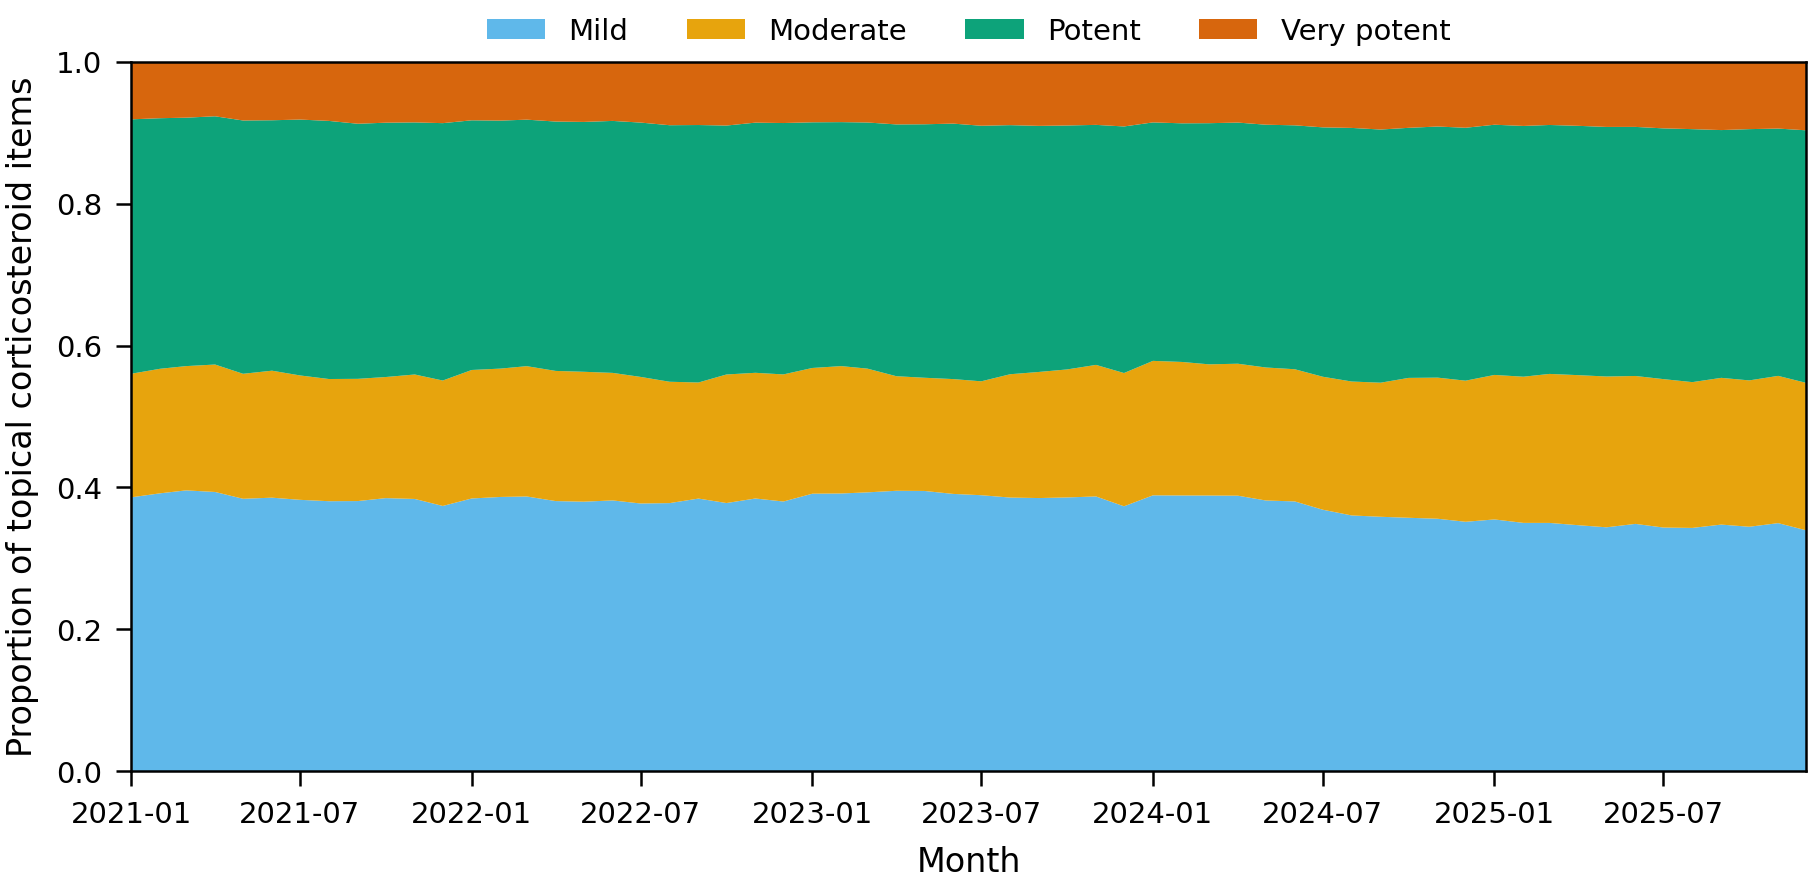

  Figure1_potency_composition.png / .pdf


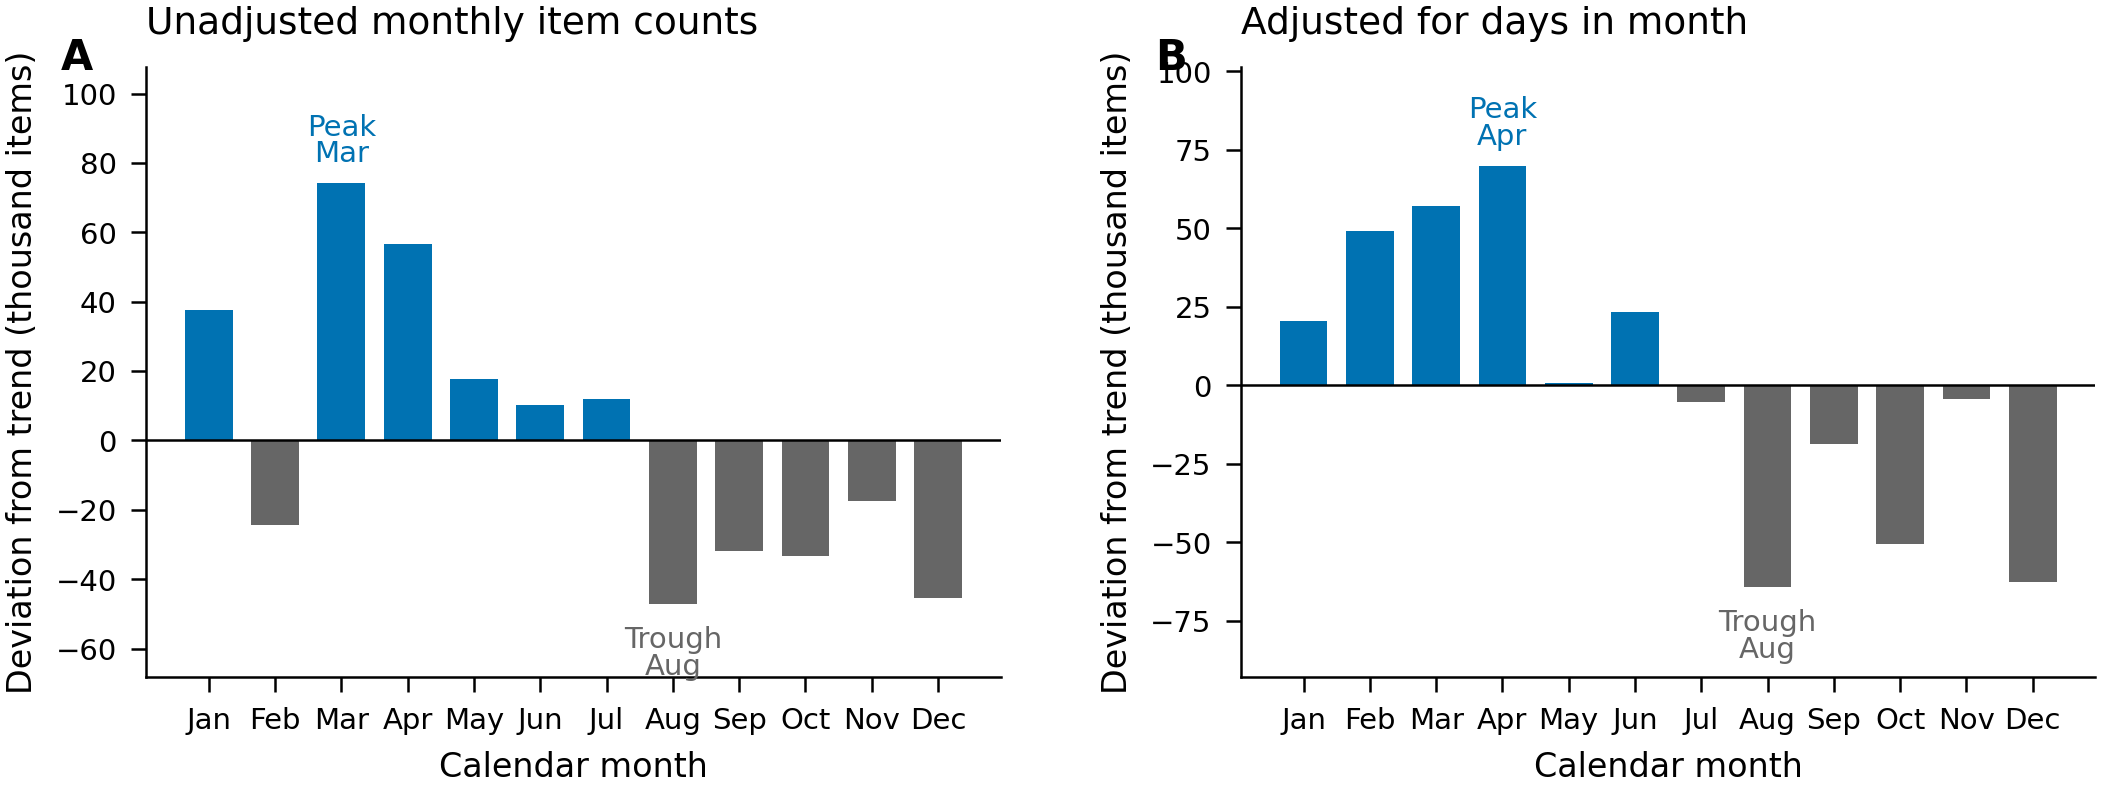

  Figure2_seasonality.png / .pdf


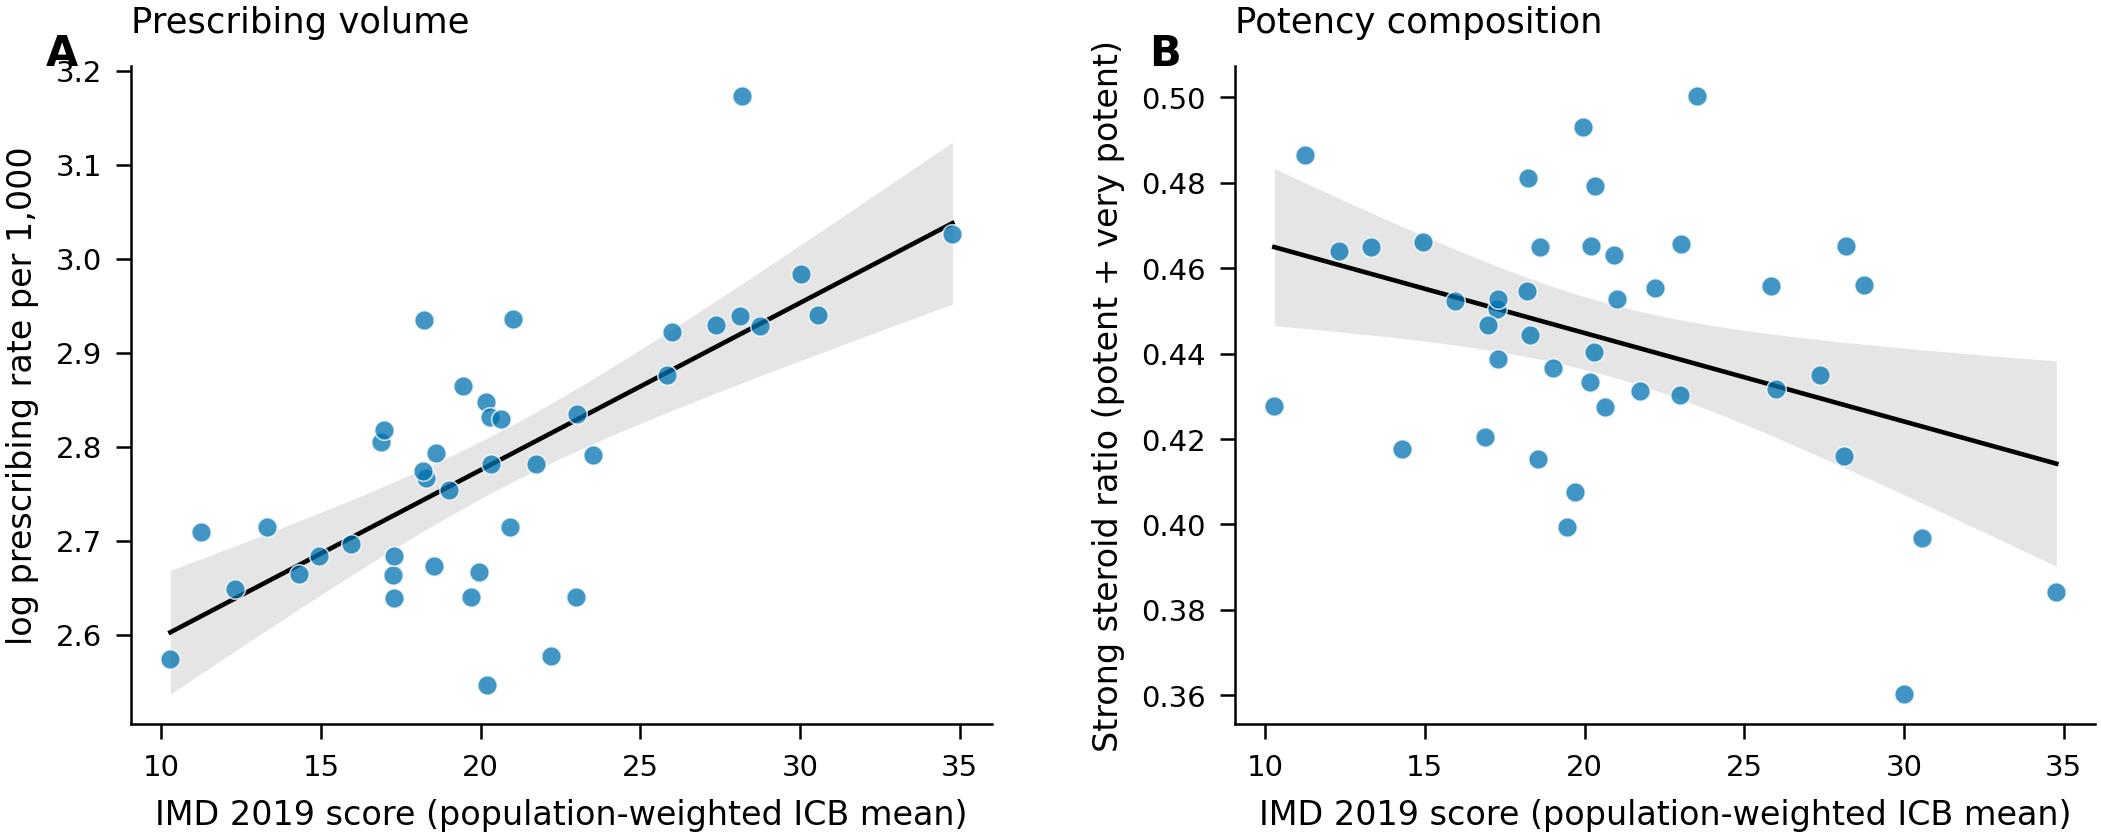

  Figure3_deprivation.png / .pdf
  map aspect (h/w) = 0.73  ->  figure 183 x 61 mm (w/h 3.01)


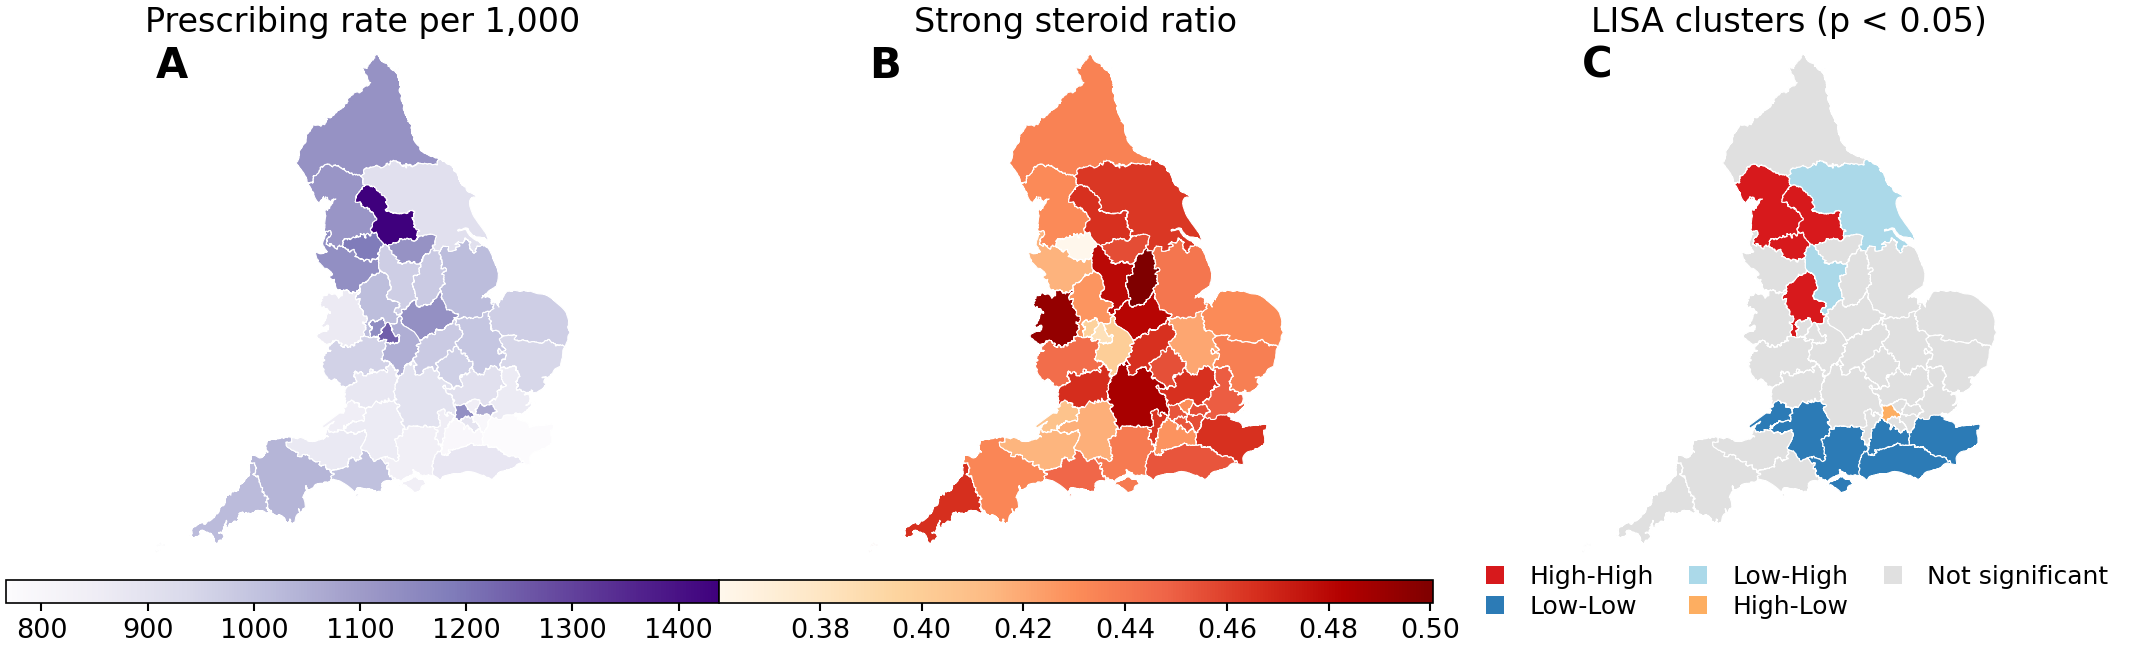

  Figure4_spatial.png / .pdf


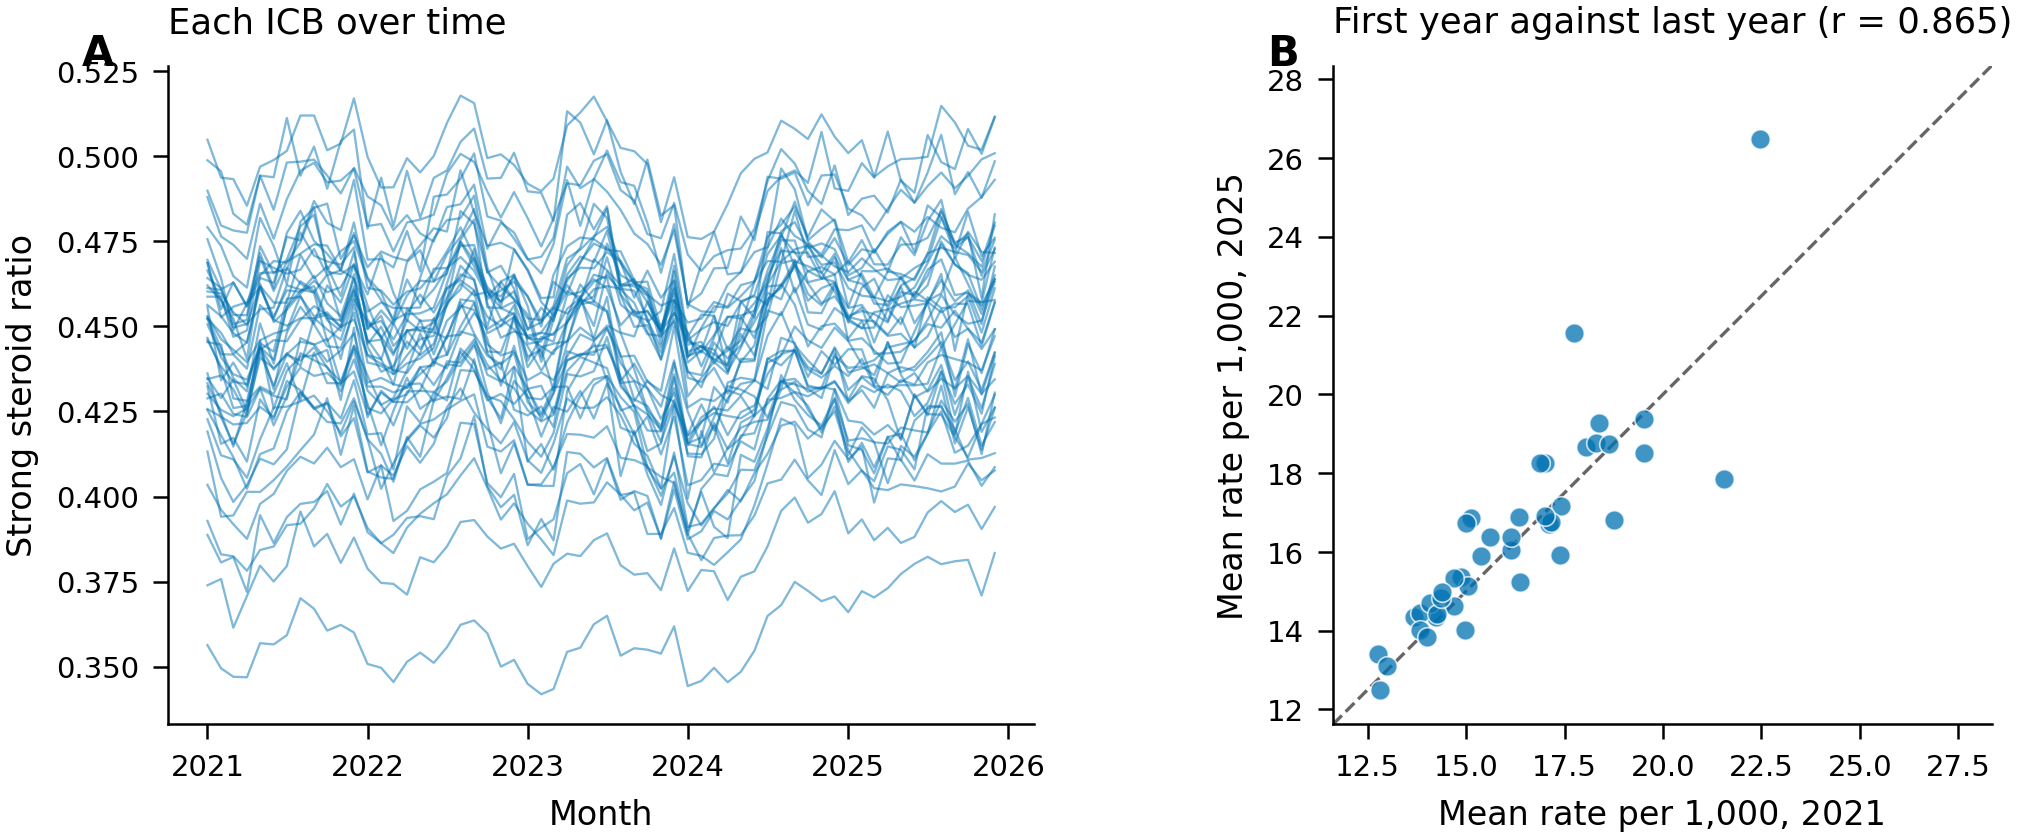

  Figure5_persistence.png / .pdf

All five figures written to /content/drive/MyDrive/KCL/Drug/outputs/figures
PDF versions are vector and are what most journals prefer for line art.


In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.api as sm
import statsmodels.formula.api as smf

banner("PUBLICATION FIGURES")

FIGDIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)

MM = 1 / 25.4
TIER_COLOURS = ["#56B4E9", "#E69F00", "#009E73", "#D55E00"]   # Okabe-Ito, colourblind-safe
ACCENT, GREY = "#0072B2", "#666666"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02, "legend.frameon": False, "lines.linewidth": 1.0,
})

def _label(ax, letter, dx=-0.10, dy=1.05):
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=10,
            fontweight="bold", va="top", ha="left")

def _save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGDIR, name + "." + ext))
    plt.show()
    print("  " + name + ".png / .pdf")

# ---------------------------------------------------------------- Figure 1
tiers = panel.groupby("YEAR_MONTH")[TIER_ORDER].sum()
share = tiers.div(tiers.sum(axis=1), axis=0).sort_index()
x = pd.to_datetime(share.index.astype(str), format="%Y%m")

fig, ax = plt.subplots(figsize=(183 * MM, 78 * MM))
ax.stackplot(x, *[share[t] for t in TIER_ORDER],
             labels=[TIER_LABELS[t] for t in TIER_ORDER], colors=TIER_COLOURS, alpha=.95)
ax.set_ylim(0, 1); ax.set_xlim(x.min(), x.max())
ax.set_ylabel("Proportion of topical corticosteroid items")
ax.set_xlabel("Month")
ax.legend(loc="upper center", bbox_to_anchor=(.5, 1.10), ncol=4)
ax.spines["top"].set_visible(True); ax.spines["right"].set_visible(True)
_save(fig, "Figure1_potency_composition")

# ---------------------------------------------------------------- Figure 2
sc = stl.seasonal.groupby(stl.seasonal.index.month).mean()
mon = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
dim = np.array([31,28,31,30,31,30,31,31,30,31,30,31])
mean_items = panel["TOTAL_ITEMS"].sum() / panel["YEAR_MONTH"].nunique()
adj = sc.values - (dim - 365.25 / 12) / (365.25 / 12) * mean_items

fig, axes = plt.subplots(1, 2, figsize=(183 * MM, 72 * MM))
for ax, vals, title in [(axes[0], sc.values, "Unadjusted monthly item counts"),
                        (axes[1], adj, "Adjusted for days in month")]:
    v = vals / 1000
    ax.bar(np.arange(12), v, color=[ACCENT if q > 0 else GREY for q in v], width=.72)
    ax.axhline(0, color="k", lw=.6)
    ax.set_xticks(np.arange(12)); ax.set_xticklabels(mon)
    ax.set_ylim(v.min() * 1.45, v.max() * 1.45)
    ax.set_xlabel("Calendar month")
    ax.set_ylabel("Deviation from trend (thousand items)")
    ax.set_title(title, loc="left", pad=8)
    for lab, i in [("Peak", int(np.argmax(v))), ("Trough", int(np.argmin(v)))]:
        up = v[i] > 0
        ax.annotate(lab + "\n" + mon[i], (i, v[i]), textcoords="offset points",
                    xytext=(0, 5 if up else -17), ha="center", fontsize=7,
                    color=ACCENT if up else GREY, linespacing=.95)
_label(axes[0], "A"); _label(axes[1], "B")
fig.tight_layout(w_pad=3)
_save(fig, "Figure2_seasonality")

# ---------------------------------------------------------------- Figure 3
icb = panel.groupby("ORG_CODE").agg(
    LOG_RATE=("LOG_RATE", "mean"), STRONG=("STRONG_RATIO", "mean"),
    IMD=("IMD_SCORE", "first")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(183 * MM, 76 * MM))
for ax, ycol, ylab, ttl in [
        (axes[0], "LOG_RATE", "log prescribing rate per 1,000",
         "Prescribing volume"),
        (axes[1], "STRONG", "Strong steroid ratio (potent + very potent)",
         "Potency composition")]:
    ax.scatter(icb["IMD"], icb[ycol], s=22, color=ACCENT, alpha=.75,
               edgecolor="white", linewidth=.4, zorder=3)
    m = smf.ols(ycol + " ~ IMD", data=icb).fit()
    xs = np.linspace(icb["IMD"].min(), icb["IMD"].max(), 100)
    pr = m.get_prediction(pd.DataFrame({"IMD": xs})).summary_frame(alpha=.05)
    ax.plot(xs, pr["mean"], color="k", lw=1.1, zorder=2)
    ax.fill_between(xs, pr["mean_ci_lower"], pr["mean_ci_upper"],
                    color="k", alpha=.10, lw=0, zorder=1)
    ax.set_xlabel("IMD 2019 score (population-weighted ICB mean)")
    ax.set_ylabel(ylab)
    ax.set_title(ttl, loc="left", pad=8, fontsize=8.5)
_label(axes[0], "A"); _label(axes[1], "B")
fig.tight_layout(w_pad=3)
_save(fig, "Figure3_deprivation")

# ---------------------------------------------------------------- Figure 4
# Two things matter here. Panel height is derived from the data bounds rather than
# guessed: England's bounding box is about 574 km wide by 653 km tall, so one map has
# an aspect near 1.14 and three across a 183 mm canvas need roughly 88 mm of height.
# And each panel gets its own appended axis of identical size beneath it, carrying a
# colourbar for A and B and the cluster key for C. Letting geopandas draw the colourbar
# inside the panel shrinks A and B but not C, which leaves the three maps misaligned.
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl

bounds = merged.total_bounds
padx = (bounds[2] - bounds[0]) * 0.02
pady = (bounds[3] - bounds[1]) * 0.02

_map_ar = (bounds[3] - bounds[1]) / (bounds[2] - bounds[0])   # map height / width
_fig_w_mm = 183.0
_panel_w_mm = _fig_w_mm / 3.0
_fig_h_mm = _panel_w_mm * _map_ar / 0.84 + 8.0                # + title and colour key
print("  map aspect (h/w) = {:.2f}  ->  figure {:.0f} x {:.0f} mm "
      "(w/h {:.2f})".format(_map_ar, _fig_w_mm, _fig_h_mm, _fig_w_mm / _fig_h_mm))

fig, axes = plt.subplots(1, 3, figsize=(_fig_w_mm * MM, _fig_h_mm * MM))

for a in axes:                     # fix extent and aspect before appending keys
    a.set_xlim(bounds[0] - padx, bounds[2] + padx)
    a.set_ylim(bounds[1] - pady, bounds[3] + pady)
    a.set_aspect("equal")
    a.axis("off")

keys = [make_axes_locatable(a).append_axes("bottom", size="4.5%", pad=0.06) for a in axes]

for ax, cax, col, cmap, ttl in [
        (axes[0], keys[0], "RATE_PER_1000", "Purples", "Prescribing rate per 1,000"),
        (axes[1], keys[1], "STRONG_RATIO", "OrRd", "Strong steroid ratio")]:
    merged.plot(column=col, cmap=cmap, edgecolor="white", lw=.25, ax=ax, legend=False)
    norm = mpl.colors.Normalize(vmin=merged[col].min(), vmax=merged[col].max())
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax,
                      orientation="horizontal")
    cb.outline.set_linewidth(.4)
    cax.tick_params(labelsize=6.5, length=2, width=.5, pad=1.5)
    ax.set_title(ttl, loc="center", pad=3, fontsize=8)

cmap_l = {"High-High": "#D7191C", "Low-Low": "#2C7BB6", "Low-High": "#ABD9E9",
          "High-Low": "#FDAE61", "Not significant": "#E0E0E0"}
present = [k for k in cmap_l if (merged["LISA"] == k).any()]
for lab in present:
    merged[merged["LISA"] == lab].plot(ax=axes[2], color=cmap_l[lab],
                                       edgecolor="white", lw=.25)
axes[2].set_title("LISA clusters (p < 0.05)", loc="center", pad=3, fontsize=8)
keys[2].axis("off")
keys[2].legend(handles=[Line2D([0], [0], marker="s", linestyle="none", markersize=4.5,
                               markerfacecolor=cmap_l[k], markeredgecolor="none", label=k)
                        for k in present],
               loc="center", ncol=3, fontsize=6, handletextpad=.35,
               columnspacing=.8, labelspacing=.25, borderpad=.15)

for a, L in zip(axes, "ABC"):
    _label(a, L, dx=0.02, dy=1.00)

fig.subplots_adjust(left=0.005, right=0.995, top=0.94, bottom=0.06, wspace=0.0)
_save(fig, "Figure4_spatial")

# ---------------------------------------------------------------- Figure 5
fig, axes = plt.subplots(1, 2, figsize=(183 * MM, 76 * MM))
for _, g in panel.groupby("ORG_CODE"):
    axes[0].plot(g["DATE"], g["STRONG_RATIO"], lw=.55, alpha=.5, color=ACCENT)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Strong steroid ratio")
axes[0].set_title("Each ICB over time", loc="left", pad=8, fontsize=8.5)

yr0, yr1 = panel["YEAR"].min(), panel["YEAR"].max()
cmp_df = (panel[panel["YEAR"].isin([yr0, yr1])]
          .groupby(["ORG_CODE", "YEAR"])["RATE_PER_1000"].mean().unstack().dropna())
axes[1].scatter(cmp_df[yr0], cmp_df[yr1], s=22, color=ACCENT, alpha=.75,
                edgecolor="white", linewidth=.4, zorder=3)
lims = [cmp_df.min().min() * .93, cmp_df.max().max() * 1.07]
axes[1].plot(lims, lims, ls="--", lw=.8, color=GREY, zorder=2)
axes[1].set_xlim(lims); axes[1].set_ylim(lims); axes[1].set_aspect("equal")
r = cmp_df.corr().iloc[0, 1]
axes[1].set_xlabel("Mean rate per 1,000, " + str(yr0))
axes[1].set_ylabel("Mean rate per 1,000, " + str(yr1))
axes[1].set_title("First year against last year (r = {:.3f})".format(r),
                  loc="left", pad=8, fontsize=8.5)
_label(axes[0], "A"); _label(axes[1], "B")
fig.tight_layout(w_pad=3)
_save(fig, "Figure5_persistence")

print("\nAll five figures written to " + os.path.abspath(FIGDIR))
print("PDF versions are vector and are what most journals prefer for line art.")

## 15. Manuscript figures summary

Everything needed to populate the manuscript, in one place. Cross-check each figure against
the corresponding claim before submitting.

In [20]:
banner("SUMMARY — FIGURES FOR THE MANUSCRIPT")

summary = pd.DataFrame([
    ("Raw data rows",                     "{:,}".format(int(load_audit["rows_raw"].sum()))),
    ("Rows retained (topical CS)",        "{:,}".format(len(prescribing))),
    ("DISPENSED ITEMS retained",          "{:,}".format(int(prescribing["ITEMS"].sum()))),
    ("Months",                            str(prescribing["YEAR_MONTH"].nunique())),
    ("Date range",                        prescribing["DATE"].min().strftime("%b %Y") + " to " +
                                          prescribing["DATE"].max().strftime("%b %Y")),
    ("ICBs in panel",                     str(panel["ORG_CODE"].nunique())),
    ("ICB-MONTH observations",            "{:,}".format(len(panel))),
    ("ICBs in spatial analysis",          str(len(merged))),
    ("Seasonal Strength Index",           "{:.4f}".format(RESULTS.get("seasonal_strength_index", np.nan))),
    ("Seasonal peak month",               str(RESULTS.get("seasonal_peak_month", "?"))),
    ("Seasonal trough month",             str(RESULTS.get("seasonal_trough_month", "?"))),
    ("Moran's I, rate per 1,000",         "{:.4f} (p = {:.4f})".format(
        RESULTS.get("morans_i_rate", np.nan), RESULTS.get("morans_i_rate_p", np.nan))),
    ("Moran's I, strong ratio",           "{:.4f} (p = {:.4f})".format(
        RESULTS.get("morans_i_strong_ratio", np.nan), RESULTS.get("morans_i_strong_ratio_p", np.nan))),
    ("ICC, log prescribing rate",         "{:.3f}".format(RESULTS.get("icc_log_rate", np.nan))),
    ("ICC, strong steroid ratio",         "{:.3f}".format(RESULTS.get("icc_strong_ratio", np.nan))),
    ("Rate stability, first vs last year","r = {:.3f}".format(RESULTS.get("rate_stability_r", np.nan))),
], columns=["Quantity", "Value"])

print(summary.to_string(index=False))
save("manuscript_summary_figures", summary)

print("\n" + "=" * 78)
print("STILL REQUIRING A DECISION BEFORE SUBMISSION")
print("=" * 78)
for line in [
    "1. Potency table: check POTENCY_RULES against the current BNF. Strength-based",
    "   assignments (betamethasone 0.025%, fluocinolone dilutions) are the ones to verify.",
    "2. Combination products are currently " + ("INCLUDED" if INCLUDE_COMBINATIONS else "EXCLUDED") +
    ". Re-run with the toggle flipped and report",
    "   whether the potency findings are sensitive to it.",
    "3. Markov: choose dominant-tier or z-score spike as primary, and describe the chosen",
    "   definition accurately in the Methods. They answer different questions.",
    "4. Denominator: confirm whether the list-size file is monthly or a single snapshot.",
    "5. Unclassifiable presentations were dropped — check the audit CSV for how many items",
    "   that represents and whether any are material.",
    "6. If any ICB appears in the prescribing data but not the IMD or boundary lookups,",
    "   resolve it rather than letting the inner join drop it.",
]:
    print(line)
print("\nAll outputs written to: " + os.path.abspath(OUT_DIR))


SUMMARY — FIGURES FOR THE MANUSCRIPT
                          Quantity                Value
                     Raw data rows           34,575,588
        Rows retained (topical CS)              446,050
          DISPENSED ITEMS retained           55,202,297
                            Months                   60
                        Date range Jan 2021 to Dec 2025
                     ICBs in panel                   42
            ICB-MONTH observations                2,520
          ICBs in spatial analysis                   42
           Seasonal Strength Index               0.6749
               Seasonal peak month                  Mar
             Seasonal trough month                  Aug
         Moran's I, rate per 1,000  0.3471 (p = 0.0004)
           Moran's I, strong ratio  0.1384 (p = 0.0533)
         ICC, log prescribing rate                0.819
         ICC, strong steroid ratio                0.880
Rate stability, first vs last year            r = 0.865
  written: